**NOTE:** Some variable names differ from those used in the main text, 
reflecting terminology changes made during the course of the study:
- 'fold' -> 'fold lineage', 'lineage'
- 'NONE' -> 'base seed'
- 'ALL' -> 'full network'

Each enzyme-gated network expansion run records iterations of network expansion as follows:
- cumiter: Tracks all individual expansion steps, including both lineage addition steps and the resulting standard network expansion steps
- folditer: Groups each lineage addition and the subsequent network expansion into a single unit; corresponds to a metabolic stage

In [1]:
from utils import*

In [2]:
def getDirectRns(cpd_id):
    direct_rns = set()
    for rn, cpds in rn2cpds.items():
        if cpd_id in cpds:
            direct_rns.add(rn)
    return direct_rns

In [3]:
# from Leave-One-Out analysis

group1 = ['2005', '4952', '184', '325', '3016', '2003', '2002', '7523', '328', '875', '602', '2486', '212', '4011', '7574', '218', '2004', '304', '7584', '206', '4953', '1', '3997', '7577', '148', '7501', '7579', '2007', '253', '7544', '101', '297', '327', '330', '141', '109', '2492']
first10 = ['2005', '4952', '325', '2003', '2002', '602', '218', '206', '4953', '2007']

In [4]:
# preATP 1000 runs

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

df_folds_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_cumiter_preATP.csv', index_col=0)
df_cpds_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_cumiter_preATP.csv', index_col=0)
df_rns_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_cumiter_preATP.csv', index_col=0)
df_rules_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_cumiter_preATP.csv', index_col=0)

In [5]:
x2foMean = {}
x2foStd = {}
for x in df_folds_folditer.index:
    if x not in ['fold_independent', 'spontaneous']:
        x2foMean[x] = np.mean(df_folds_folditer.loc[x])
        x2foStd[x] = np.std(df_folds_folditer.loc[x])

print(len(x2foMean))
print(len(x2foStd))

396
396


In [6]:
rns_scope = list(df_rns_folditer[df_rns_folditer.columns[0]].keys())
len(rns_scope)

7678

# 1. Direct vs. indirect reactions
- direct := reaction has the cpd in its eqn (reac or prod)
- indirect := reaction does NOT have the cpd in its eqn, but is unreachable when cpd in ablated

### get direct cofactor reactions from SI

In [7]:
# get 'direct' reactions from SI list of rns

direct_rns_SI_O2 = getDirectRns('C00007')
print(len(direct_rns_SI_O2))
direct_rns_SI_CoA = getDirectRns('C00010') | getDirectRns('Z00051')
print(len(direct_rns_SI_CoA))
direct_rns_SI_ATP = getDirectRns('C00002') | getDirectRns('C00008')
print(len(direct_rns_SI_ATP))
direct_rns_SI_SAM = getDirectRns('C00019') | getDirectRns('Z00041') # C00021 (SAH) is accessible before SAM; do not include here
print(len(direct_rns_SI_SAM))
direct_rns_SI_FAD = getDirectRns('C00016') | getDirectRns('Z00013') | getDirectRns('C01352')
print(len(direct_rns_SI_FAD))
direct_rns_SI_NAD = getDirectRns('C00003') | getDirectRns('Z00032') | getDirectRns('C00004')  # Z00032 = 'NAD/NADP'
print(len(direct_rns_SI_NAD))
direct_rns_SI_NADP = getDirectRns('C00005') | getDirectRns('Z00032') | getDirectRns('C00006')
print(len(direct_rns_SI_NADP))
direct_rns_SI_PLP = getDirectRns('C00018') | getDirectRns('Z00035')
print(len(direct_rns_SI_PLP))
direct_rns_SI_ThDP = getDirectRns('C00068') | getDirectRns('Z00047')
print(len(direct_rns_SI_ThDP))
direct_rns_SI_FMN = getDirectRns('C00061') | getDirectRns('Z00014') | getDirectRns('C01847')
print(len(direct_rns_SI_FMN))
direct_rns_SI_Cobalamin = getDirectRns('Z00009')
print(len(direct_rns_SI_Cobalamin))
direct_rns_SI_AcetylCoA = getDirectRns('C00024')
print(len(direct_rns_SI_AcetylCoA))
direct_rns_SI_IPP = getDirectRns('C00129')
print(len(direct_rns_SI_IPP))

1638
659
843
581
732
1384
1389
386
103
250
50
218
50


### get unreached reactions from ablation (direct or indirect)

In [8]:
with open('../data/rns_unreached_wo/rns_unreached_wo_O2.pkl', 'rb') as file:
    unreached_O2 = pickle.load(file)
print(len(unreached_O2))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_CoA_zCoA.pkl', 'rb') as file:
    unreached_CoA = pickle.load(file)
print(len(unreached_CoA))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_ATP_ADP.pkl', 'rb') as file:
    unreached_ATP = pickle.load(file)
print(len(unreached_ATP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_SAM_zSAM.pkl', 'rb') as file:
    unreached_SAM = pickle.load(file)
print(len(unreached_SAM))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_FAD_FADH2_zFAD.pkl', 'rb') as file:
    unreached_FAD = pickle.load(file)
print(len(unreached_FAD))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_NAD_NADH_zNAD.pkl', 'rb') as file:
    unreached_NAD = pickle.load(file)
print(len(unreached_NAD))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_NADP_NADPH_zNADP.pkl', 'rb') as file:
    unreached_NADP = pickle.load(file)
print(len(unreached_NADP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_PLP_zPLP.pkl', 'rb') as file:
    unreached_PLP = pickle.load(file)
print(len(unreached_PLP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_ThDP_zThDP.pkl', 'rb') as file:
    unreached_ThDP = pickle.load(file)
print(len(unreached_ThDP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_FMN_zFMN.pkl', 'rb') as file:
    unreached_FMN = pickle.load(file)
print(len(unreached_FMN))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_IPP.pkl', 'rb') as file:
    unreached_IPP = pickle.load(file)
print(len(unreached_IPP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_zCobalamin.pkl', 'rb') as file:
    unreached_Cobalamin = pickle.load(file)
print(len(unreached_Cobalamin))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_AcetylCoA.pkl', 'rb') as file:
    unreached_AcetylCoA = pickle.load(file)
print(len(unreached_AcetylCoA))  # from ablation

1673
3788
6788
3134
2121
6591
4259
5380
1894
3590
2304
87
2911


In [9]:
# get 'indirect' reactions:
    # 1. get reactions unreachable without cofactor (cpd ablation) from actual vanilla run
    # 2. subtract 'direct' from that
# get 'direct' reactions:
    # 1. get reactions unreachable without cofactor (cpd ablation) from actual vanilla run
    # 2. get overlap with direct_reactions from SI
    # 3. check to make sure it's the same as len(direct_rns_SI_cofactor & set(rns_scope))

indirectO2 = unreached_O2 - direct_rns_SI_O2
directO2 = unreached_O2 & direct_rns_SI_O2
print('O2: ', len(indirectO2), len(directO2), len(direct_rns_SI_O2 & set(rns_scope)))

indirectATP = unreached_ATP - direct_rns_SI_ATP 
directATP = unreached_ATP & direct_rns_SI_ATP
print('ATP:',len(indirectATP), len(directATP), len(direct_rns_SI_ATP & set(rns_scope)))

indirectCoA = unreached_CoA - direct_rns_SI_CoA
directCoA = unreached_CoA & direct_rns_SI_CoA
print('CoA:', len(indirectCoA), len(directCoA), len(direct_rns_SI_CoA & set(rns_scope)))

indirectSAM = unreached_SAM - direct_rns_SI_SAM
directSAM = unreached_SAM & direct_rns_SI_SAM
print('SAM:', len(indirectSAM), len(directSAM), len(direct_rns_SI_SAM & set(rns_scope)))

indirectFAD = unreached_FAD - direct_rns_SI_FAD
directFAD = unreached_FAD & direct_rns_SI_FAD
print('FAD:', len(indirectFAD), len(directFAD), len(direct_rns_SI_FAD & set(rns_scope)))

indirectNAD = unreached_NAD - direct_rns_SI_NAD
directNAD = unreached_NAD & direct_rns_SI_NAD
print('NAD:', len(indirectNAD), len(directNAD), len(direct_rns_SI_NAD & set(rns_scope)))

indirectNADP = unreached_NADP - direct_rns_SI_NADP
directNADP = unreached_NADP & direct_rns_SI_NADP
print('NADP:', len(indirectNADP), len(directNADP), len(direct_rns_SI_NADP & set(rns_scope)))

indirectPLP = unreached_PLP - direct_rns_SI_PLP
directPLP = unreached_PLP & direct_rns_SI_PLP
print('PLP:', len(indirectPLP), len(directPLP), len(direct_rns_SI_PLP & set(rns_scope)))

indirectThDP = unreached_ThDP - direct_rns_SI_ThDP
directThDP = unreached_ThDP & direct_rns_SI_ThDP
print('ThDP:', len(indirectThDP), len(directThDP), len(direct_rns_SI_ThDP & set(rns_scope)))

indirectFMN = unreached_FMN - direct_rns_SI_FMN
directFMN = unreached_FMN & direct_rns_SI_FMN
print('FMN:', len(indirectFMN), len(directFMN), len(direct_rns_SI_FMN & set(rns_scope)))

indirectCobalamin = unreached_Cobalamin - direct_rns_SI_Cobalamin
directCobalamin = unreached_Cobalamin & direct_rns_SI_Cobalamin
print('Cobalamin:', len(indirectCobalamin), len(directCobalamin), len(direct_rns_SI_Cobalamin & set(rns_scope)))

indirectIPP = unreached_IPP - direct_rns_SI_IPP
directIPP = unreached_IPP & direct_rns_SI_IPP
print('IPP:', len(indirectIPP), len(directIPP), len(direct_rns_SI_IPP & set(rns_scope)))

indirectAcetylCoA = unreached_AcetylCoA - direct_rns_SI_AcetylCoA
directAcetylCoA = unreached_AcetylCoA & direct_rns_SI_AcetylCoA
print('AcetylCoA:', len(indirectAcetylCoA), len(directAcetylCoA), len(direct_rns_SI_AcetylCoA & set(rns_scope)))

O2:  826 847 847
ATP: 6142 646 646
CoA: 3325 463 463
SAM: 2800 334 334
FAD: 1631 490 490
NAD: 5716 875 875
NADP: 3400 859 859
PLP: 5032 348 348
ThDP: 1798 96 96
FMN: 3411 179 179
Cobalamin: 50 37 37
IPP: 2255 49 49
AcetylCoA: 2747 164 164


#### what if we ignore Z cpds?

In [10]:
# ignore Z compounds
print('      C+Z  C')
print('-------------')

direct_rns_SI_CoA_C = getDirectRns('C00010')
print('CoA: ',len(direct_rns_SI_CoA), len(direct_rns_SI_CoA_C))
direct_rns_SI_ATP_C = getDirectRns('C00002')
print('ATP: ',len(direct_rns_SI_ATP), len(direct_rns_SI_ATP_C))
direct_rns_SI_SAM_C = getDirectRns('C00019')
print('SAM: ',len(direct_rns_SI_SAM), len(direct_rns_SI_SAM_C))
direct_rns_SI_FAD_C = getDirectRns('C00016')
print('FAD: ',len(direct_rns_SI_FAD), len(direct_rns_SI_FAD_C))
direct_rns_SI_NAD_C = getDirectRns('C00003')
print('NAD: ',len(direct_rns_SI_NAD), len(direct_rns_SI_NAD_C))
direct_rns_SI_NADP_C = getDirectRns('C00005')
print('NADP:',len(direct_rns_SI_NADP), len(direct_rns_SI_NADP_C))
direct_rns_SI_PLP_C = getDirectRns('C00018')
print('PLP: ',len(direct_rns_SI_PLP), len(direct_rns_SI_PLP_C))
direct_rns_SI_ThDP_C = getDirectRns('C00068')
print('ThDP:',len(direct_rns_SI_ThDP), len(direct_rns_SI_ThDP_C))
direct_rns_SI_FMN_C = getDirectRns('C00061')
print('FMN: ',len(direct_rns_SI_FMN), len(direct_rns_SI_FMN_C))

      C+Z  C
-------------
CoA:  659 638
ATP:  843 796
SAM:  581 564
FAD:  732 93
NAD:  1384 1078
NADP: 1389 1080
PLP:  386 15
ThDP: 103 28
FMN:  250 72


In [11]:
directFMN_C = unreached_FMN & direct_rns_SI_FMN_C
print('FMN: ', len(directFMN), len(directFMN_C), len([rn for rn in directFMN_C if rn2rev[rn]]), len([rn for rn in directFMN_C if not rn2rev[rn]]))

FMN:  179 40 25 15


In [12]:
directO2_C = unreached_O2 & direct_rns_SI_O2
print('O2: ', len(directO2), len([rn for rn in directO2 if rn2rev[rn]]))
[rn for rn in directO2 if rn2rev[rn]]

# only 1 O2 reactions is 'reversible'!

O2:  847 1


['R09503_vX']

In [13]:
print('     C+Z C rev n_rev')
print('-------------------------')

print('O2:  ', '-', len(directO2), len([rn for rn in directO2 if rn2rev[rn]]), len([rn for rn in directO2 if not rn2rev[rn]]))
directCoA_C = unreached_CoA & direct_rns_SI_CoA_C
print('CoA: ', len(directCoA), len(directCoA_C), len([rn for rn in directCoA_C if rn2rev[rn]]), len([rn for rn in directCoA_C if not rn2rev[rn]]))
directATP_C = unreached_ATP & direct_rns_SI_ATP_C
print('ATP: ', len(directATP), len(directATP_C), len([rn for rn in directATP_C if rn2rev[rn]]), len([rn for rn in directATP_C if not rn2rev[rn]]))
directSAM_C = unreached_SAM & direct_rns_SI_SAM_C
print('SAM: ', len(directSAM), len(directSAM_C), len([rn for rn in directSAM_C if rn2rev[rn]]), len([rn for rn in directSAM_C if not rn2rev[rn]]))
directFAD_C = unreached_FAD & direct_rns_SI_FAD_C
print('FAD: ', len(directFAD), len(directFAD_C), len([rn for rn in directFAD_C if rn2rev[rn]]), len([rn for rn in directFAD_C if not rn2rev[rn]]))
directNAD_C = unreached_NAD & direct_rns_SI_NAD_C
print('NAD: ', len(directNAD), len(directNAD_C), len([rn for rn in directNAD_C if rn2rev[rn]]), len([rn for rn in directNAD_C if not rn2rev[rn]]))
directNADP_C = unreached_NADP & direct_rns_SI_NADP_C
print('NADP:', len(directNADP), len(directNADP_C), len([rn for rn in directNADP_C if rn2rev[rn]]), len([rn for rn in directNADP_C if not rn2rev[rn]]))
directPLP_C = unreached_PLP & direct_rns_SI_PLP_C
print('PLP: ', len(directPLP), len(directPLP_C), len([rn for rn in directPLP_C if rn2rev[rn]]), len([rn for rn in directPLP_C if not rn2rev[rn]]))
directThDP_C = unreached_ThDP & direct_rns_SI_ThDP_C
print('ThDP: ', len(directThDP), len(directThDP_C), len([rn for rn in directThDP_C if rn2rev[rn]]), len([rn for rn in directThDP_C if not rn2rev[rn]]))
directFMN_C = unreached_FMN & direct_rns_SI_FMN_C
print('FMN: ', len(directFMN), len(directFMN_C), len([rn for rn in directFMN_C if rn2rev[rn]]), len([rn for rn in directFMN_C if not rn2rev[rn]]))

     C+Z C rev n_rev
-------------------------
O2:   - 847 1 846
CoA:  463 445 351 94
ATP:  646 606 559 47
SAM:  334 320 291 29
FAD:  490 53 45 8
NAD:  875 661 538 123
NADP: 859 644 472 172
PLP:  348 15 8 7
ThDP:  96 28 20 8
FMN:  179 40 25 15


### calculate fraction of reactions that are direct cofactor-utilizing 

In [14]:
# make x2rn with the same scope as our simulations

x2rn_scope = {}
for x, rns in x2rn.items():
    scope_rns = []
    for rn in rns:
        if rn in rns_scope:  # check if rn appears in our simulations
            scope_rns.append(rn)
    x2rn_scope[x] = scope_rns

In [15]:
def makeCofactorDicts(direct_rns, indirect_rns):
    # make categorical dict
    x2rn_cofactor = {}
    for x, rns in x2rn_scope.items():
        fracdict = {'direct':[], 'indirect':[], 'total':[]}
        for rn in rns:
            if rn in direct_rns:
                fracdict['direct'].append(rn)
            if rn in indirect_rns:
                fracdict['indirect'].append(rn)
            fracdict['total'].append(rn)
        x2rn_cofactor[x] = fracdict
    
    # make fraction dict
    x2rnFrac_cofactor = {}
    for x, d in x2rn_cofactor.items():
        dir_total = len(d['direct']) / len(d['total'])
        ind_total = len(d['indirect']) / len(d['total'])
        dir_ind_total = len((set(d['direct']) | set(d['indirect']))) / len(d['total'])
        x2rnFrac_cofactor[x] = [dir_total, ind_total, dir_ind_total]
    
    return x2rn_cofactor, x2rnFrac_cofactor

In [16]:
x2rn_O2, x2rnFrac_O2 = makeCofactorDicts(directO2, indirectO2)
x2rn_ATP, x2rnFrac_ATP = makeCofactorDicts(directATP, indirectATP)
x2rn_CoA, x2rnFrac_CoA = makeCofactorDicts(directCoA, indirectCoA)
x2rn_SAM, x2rnFrac_SAM = makeCofactorDicts(directSAM, indirectSAM)
x2rn_FAD, x2rnFrac_FAD = makeCofactorDicts(directFAD, indirectFAD)

x2rn_NAD, x2rnFrac_NAD = makeCofactorDicts(directNAD, indirectNAD)
x2rn_NADP, x2rnFrac_NADP = makeCofactorDicts(directNADP, indirectNADP)
x2rn_PLP, x2rnFrac_PLP = makeCofactorDicts(directPLP, indirectPLP)
x2rn_ThDP, x2rnFrac_ThDP = makeCofactorDicts(directThDP, indirectThDP)

x2rn_FMN, x2rnFrac_FMN = makeCofactorDicts(directFMN, indirectFMN)
x2rn_IPP, x2rnFrac_IPP = makeCofactorDicts(directIPP, indirectIPP)
x2rn_Cobalamin, x2rnFrac_Cobalamin = makeCofactorDicts(directCobalamin, indirectCobalamin)
x2rn_AcetylCoA, x2rnFrac_AcetylCoA = makeCofactorDicts(directAcetylCoA, indirectAcetylCoA)

### separate fractions

In [17]:
x2rnFrac_O2_0 = {x:values[0] for x, values in x2rnFrac_O2.items()}
x2rnFrac_O2_1 = {x:values[1] for x, values in x2rnFrac_O2.items()}
x2rnFrac_O2_2 = {x:values[2] for x, values in x2rnFrac_O2.items()}

x2rnFrac_ATP_0 = {x:values[0] for x, values in x2rnFrac_ATP.items()}
x2rnFrac_ATP_1 = {x:values[1] for x, values in x2rnFrac_ATP.items()}
x2rnFrac_ATP_2 = {x:values[2] for x, values in x2rnFrac_ATP.items()}

x2rnFrac_CoA_0 = {x:values[0] for x, values in x2rnFrac_CoA.items()}
x2rnFrac_CoA_1 = {x:values[1] for x, values in x2rnFrac_CoA.items()}
x2rnFrac_CoA_2 = {x:values[2] for x, values in x2rnFrac_CoA.items()}

x2rnFrac_SAM_0 = {x:values[0] for x, values in x2rnFrac_SAM.items()}
x2rnFrac_SAM_1 = {x:values[1] for x, values in x2rnFrac_SAM.items()}
x2rnFrac_SAM_2 = {x:values[2] for x, values in x2rnFrac_SAM.items()}

x2rnFrac_FAD_0 = {x:values[0] for x, values in x2rnFrac_FAD.items()}
x2rnFrac_FAD_1 = {x:values[1] for x, values in x2rnFrac_FAD.items()}
x2rnFrac_FAD_2 = {x:values[2] for x, values in x2rnFrac_FAD.items()}

x2rnFrac_NAD_0 = {x:values[0] for x, values in x2rnFrac_NAD.items()}
x2rnFrac_NAD_1 = {x:values[1] for x, values in x2rnFrac_NAD.items()}
x2rnFrac_NAD_2 = {x:values[2] for x, values in x2rnFrac_NAD.items()}

x2rnFrac_NADP_0 = {x:values[0] for x, values in x2rnFrac_NADP.items()}
x2rnFrac_NADP_1 = {x:values[1] for x, values in x2rnFrac_NADP.items()}
x2rnFrac_NADP_2 = {x:values[2] for x, values in x2rnFrac_NADP.items()}

x2rnFrac_PLP_0 = {x:values[0] for x, values in x2rnFrac_PLP.items()}
x2rnFrac_PLP_1 = {x:values[1] for x, values in x2rnFrac_PLP.items()}
x2rnFrac_PLP_2 = {x:values[2] for x, values in x2rnFrac_PLP.items()}

x2rnFrac_ThDP_0 = {x:values[0] for x, values in x2rnFrac_ThDP.items()}
x2rnFrac_ThDP_1 = {x:values[1] for x, values in x2rnFrac_ThDP.items()}
x2rnFrac_ThDP_2 = {x:values[2] for x, values in x2rnFrac_ThDP.items()}

x2rnFrac_FMN_0 = {x:values[0] for x, values in x2rnFrac_FMN.items()}
x2rnFrac_FMN_1 = {x:values[1] for x, values in x2rnFrac_FMN.items()}
x2rnFrac_FMN_2 = {x:values[2] for x, values in x2rnFrac_FMN.items()}

x2rnFrac_IPP_0 = {x:values[0] for x, values in x2rnFrac_IPP.items()}
x2rnFrac_IPP_1 = {x:values[1] for x, values in x2rnFrac_IPP.items()}
x2rnFrac_IPP_2 = {x:values[2] for x, values in x2rnFrac_IPP.items()}

x2rnFrac_Cobalamin_0 = {x:values[0] for x, values in x2rnFrac_Cobalamin.items()}
x2rnFrac_Cobalamin_1 = {x:values[1] for x, values in x2rnFrac_Cobalamin.items()}
x2rnFrac_Cobalamin_2 = {x:values[2] for x, values in x2rnFrac_Cobalamin.items()}

x2rnFrac_AcetylCoA_0 = {x:values[0] for x, values in x2rnFrac_AcetylCoA.items()}
x2rnFrac_AcetylCoA_1 = {x:values[1] for x, values in x2rnFrac_AcetylCoA.items()}
x2rnFrac_AcetylCoA_2 = {x:values[2] for x, values in x2rnFrac_AcetylCoA.items()}

### get 'direct' lineages that have cofactors in equation

In [18]:
direct_lineages_O2 = [x for x,v in x2rnFrac_O2.items() if v[0] > 0]
print(len(direct_lineages_O2))
direct_lineages_ATP = [x for x,v in x2rnFrac_ATP.items() if v[0] > 0]
print(len(direct_lineages_ATP))
direct_lineages_CoA = [x for x,v in x2rnFrac_CoA.items() if v[0] > 0]
print(len(direct_lineages_CoA))
direct_lineages_SAM = [x for x,v in x2rnFrac_SAM.items() if v[0] > 0]
print(len(direct_lineages_SAM))
direct_lineages_FAD = [x for x,v in x2rnFrac_FAD.items() if v[0] > 0]
print(len(direct_lineages_FAD))
direct_lineages_NAD = [x for x,v in x2rnFrac_NAD.items() if v[0] > 0]
print(len(direct_lineages_NAD))
direct_lineages_NADP = [x for x,v in x2rnFrac_NADP.items() if v[0] > 0]
print(len(direct_lineages_NADP))
direct_lineages_PLP = [x for x,v in x2rnFrac_PLP.items() if v[0] > 0]
print(len(direct_lineages_PLP))
direct_lineages_ThDP = [x for x,v in x2rnFrac_ThDP.items() if v[0] > 0]
print(len(direct_lineages_ThDP))
direct_lineages_IPP = [x for x,v in x2rnFrac_IPP.items() if v[0] > 0]
print(len(direct_lineages_IPP))
direct_lineages_FMN = [x for x,v in x2rnFrac_FMN.items() if v[0] > 0]
print(len(direct_lineages_FMN))
direct_lineages_Cobalamin = [x for x,v in x2rnFrac_Cobalamin.items() if v[0] > 0]
print(len(direct_lineages_Cobalamin))
direct_lineages_AcetylCoA = [x for x,v in x2rnFrac_AcetylCoA.items() if v[0] > 0]
print(len(direct_lineages_AcetylCoA))

88
132
79
40
89
127
120
41
22
8
75
16
63


# 2. ETU (Emerge to Use) lineages

In [19]:
# # this takes a while
# # collect cumiter2rules for all 1000 runs

# cumiter2rules_all_runs = {}
# for run in df_rules_cumiter:
#     cumiter2rules = {}
#     for rule, i in df_rules_cumiter[run].items():
#         if i not in cumiter2rules:
#             cumiter2rules[i] = [eval(rule)]  # convert string into tuple with 'eval'
#         else:
#             cumiter2rules[i].append(eval(rule))
#     cumiter2rules_all_runs[run] = cumiter2rules

# with open('../data/assets/cumiter2rules_all_runs.pkl', 'wb') as file:
#     pickle.dump(cumiter2rules_all_runs, file)

In [20]:
cumiter2rules_all_runs = pd.read_pickle('../data/assets/cumiter2rules_all_runs.pkl')

### helper function to differentiate cofactor 'using' and 'producing' reactions

In [21]:
# helper function to return reactions that 'use' or 'produce' given cofactor when discovered
# change the condition in 'else' to either:
    # (1) compare cumiters of cpds to decide direction of rev reactions
    # (2) return reac_iters and prod_iters to compare with fold-cumiter in main function

def getUsingProducingRns(run, cofactor, direct_cofactor_rns):
    cofactor_using = []
    both = {}
    cofactor_producing = []

    if cofactor.startswith('Z'):
        print('this function cannot be used with Z compounds, since they are not consumed!')
        return None
    
    for rn in direct_cofactor_rns:

        if rn2direction[rn] == 'forward':
            if cofactor in rn2prod[rn]: # forward AND cpd is in prod
                cofactor_producing.append(rn) 
            else:
                cofactor_using.append(rn)
        elif rn2direction[rn] == 'reverse':
            if cofactor in rn2reac[rn]: # reverse AND cpd is in reac
                cofactor_producing.append(rn) 
            else:
                cofactor_using.append(rn)
        else:  # reversible 
            reac_iters = [df_cpds_cumiter[run][c] for c in rn2reac[rn]]
            prod_iters = [df_cpds_cumiter[run][c] for c in rn2prod[rn]]
            
            # # (1) compare cumiter of cpds
            # if max(reac_iters) > max(prod_iters):  # reverse
            #     if cofactor in rn2prod[rn]:
            #         cofactor_using.append(rn)
            #     else:
            #         cofactor_producing.append(rn)
            # elif max(reac_iters) < max(prod_iters):  # forward
            #     if cofactor in rn2reac[rn]:
            #         cofactor_using.append(rn)
            #     else:
            #         cofactor_producing.append(rn)
            # else:  # same max cumiter
            #     both.append(rn)

            # (2) instead, return max cumiters of reac and prod to be compared to 'fold cumiter' later
            both[rn] = (max(reac_iters), max(prod_iters))
            
    return cofactor_using, both, cofactor_producing

# example
run = '87452'
cofactor = 'C00007'
direct_cofactor_rns = directO2
using, both, producing = getUsingProducingRns(run, cofactor, direct_cofactor_rns)
print(len(directO2), len(using), len(both), len(producing))

847 826 1 20


In [22]:
# check all of them
cid2directRns = {'C00007': directO2, 'C00002': directATP, 'C00010': directCoA, 'C00019': directSAM, 'C00016': directFAD, 'C00003': directNAD, 'C00005': directNADP, 'C00018': directPLP, 'C00068': directThDP, 'C00061': directFMN, 'C00129': directIPP, 'C00024': directAcetylCoA}
run = '87452'
for cid, direct_cofactor_rns in cid2directRns.items():
    using, both, producing = getUsingProducingRns(run, cid, direct_cofactor_rns)
    print(cid, len(direct_cofactor_rns), len(using), len(both), len(producing))

C00007 847 826 1 20
C00002 646 43 595 8
C00010 463 18 368 77
C00019 334 32 302 0
C00016 490 298 188 4
C00003 875 136 648 91
C00005 859 258 582 19
C00018 348 71 272 5
C00068 96 20 69 7
C00061 179 75 94 10
C00129 49 34 14 1
C00024 164 14 147 3


### getETC_UC: function to collect lineages that 'emerge to use' a given cpd

In [23]:
# Do not differentiate use vs. produce
def getETU_UC_direct(direct_cofactor_rn_set, direct_cofactor_lineage_set=None, mode='strict'):
    
    recruited_lineages_allruns = []
    for run, cumiter2rules in cumiter2rules_all_runs.items():
        
        # collect a list of rnRules discovered at the same time as lineage addition
        x2first_rules = {} 
        for x, i in df_folds_cumiter[run].items():
            if direct_cofactor_lineage_set == None:  # no lineage_set given
                if x != 'fold_independent':
                    x2first_rules[x] = cumiter2rules[i]
            else:
                if x in direct_cofactor_lineage_set:  # only look at lineages we already know have cofactor-using reactions
                    x2first_rules[x] = cumiter2rules[i]
                
        if mode == 'loose':
            # LOOSE: ETU if ANY reaction has cofactor ('direct')
            recruited_lineages = set()
            for x, rules in x2first_rules.items():
                for rule in rules:
                    if rule[0] in direct_cofactor_rn_set:  # direct cofactor rns 
                        recruited_lineages.add(x)
        
        elif mode == 'strict':
            # STRICT: ETU if ALL reactions have cofactor ('direct')
            recruited_lineages = set()
            for x, rules in x2first_rules.items():
                count = 0
                # count num of cofactor reactions
                for rule in rules:
                    if rule[0] in direct_cofactor_rn_set:  # direct cofactor rns 
                        count += 1
                if count == len(rules):  # if all reactions use the cofactor
                    recruited_lineages.add(x)        

        else:
            print('unrecognized mode name')
            return

        recruited_lineages_allruns.append(recruited_lineages)

    # tally of all lineages
    l = []  
    for run in recruited_lineages_allruns:
        for x in run:
            l.append(x)
    
    # divide based on threshold
    emerged_to_use = set()
    unclassified = set()
    for x in set(l):
#         print(l.count(x)/len(df_rules_cumiter.columns))
        if l.count(x)/len(df_rules_cumiter.columns) >= 0.75:  # change threshold here
            emerged_to_use.add(x)
        else:
            unclassified.add(x)

    # return the set of lineages 'recruited for' the cofactor
    return emerged_to_use, unclassified

In [24]:
# Differentiate use vs. produce

def getETU_UC_using(cofactor, direct_cofactor_rn_set, direct_cofactor_lineage_set=None, mode='strict'):
    recruited_lineages_allruns = []
    # just use one run to get using/producing reactions (2a)
    run = '87452'
    using, both, producing = getUsingProducingRns(run, cofactor, direct_cofactor_rn_set)
    
    for run, cumiter2rules in cumiter2rules_all_runs.items():
        # uncomment if using (2b) option below
        # using, both, producing = getUsingProducingRns(run, cofactor, direct_cofactor_rn_set)
        
        # collect a list of rnRules discovered at the same time as lineage addition
        x2first_rules = {} 
        for x, i in df_folds_cumiter[run].items():
            if direct_cofactor_lineage_set == None:  # no lineage_set given
                if x != 'fold_independent':
                    x2first_rules[x] = cumiter2rules[i]
            else:
                if x in direct_cofactor_lineage_set:  # only look at lineages we already know have cofactor-using reactions
                    x2first_rules[x] = cumiter2rules[i]
                
        # go through the reactions and determine their direction => collect cases where the lineage 'used' the cofactor
        if mode == 'loose':
            # LOOSE: ETU if ANY reaction uses the cofactor
            recruited_lineages = set()
            for x, rules in x2first_rules.items():
                for rule in rules:
                    if rule[0] in using:  # use the cofactor 
                        recruited_lineages.add(x)
        
        elif mode == 'strict':
            # STRICT: ETU if ALL reactions use the cofactor
            recruited_lineages = set()
            for x, rules in x2first_rules.items():
                count = 0
                for rule in rules:
    
                    # differentiate usage vs. production (reactant vs. product)
                    if rule[0] in using:  # direct cofactor USING rns 
                        count += 1
                    if rule[0] in both:
                        # (2a) just add them to recruit
                        count += 1
                        
                        # # (2b) more stringent; check for cpds that were gated by the lineage
                        # max_reac = both[rule[0]][0]  # max cumiter cpd in reac
                        # max_prod = both[rule[0]][0]  # max cumiter cpd in prod
                        # if df_folds_cumiter[run][x] == max_prod and cofactor in rn2reac[rule[0]]:
                        #     recruited_lineages.add(x)
                        # elif df_folds_cumiter[run][x] == max_reac and cofactor in rn2prod[rule[0]]:
                        #     recruited_lineages.add(x)
                        # else:
                        #     'this should not print'
                        #     return
                if count == len(rules):
                    recruited_lineages.add(x)

        else:
            print('unrecognized mode name')
            return

        recruited_lineages_allruns.append(recruited_lineages)

    # tally of all lineages
    l = []  
    for run in recruited_lineages_allruns:
        for x in run:
            l.append(x)
    
    # divide based on threshold
    emerged_to_use = set()
    unclassified = set()
    
    for x in set(l):
        # print(x, l.count(x)/len(df_rules_cumiter.columns))
        if l.count(x)/len(df_rules_cumiter.columns) >= 0.75:  # change threshold here
            emerged_to_use.add(x)
        else:
            unclassified.add(x)

    # return the set of lineages 'recruited for' the cofactor
    return emerged_to_use, unclassified

In [25]:
ETU_O2_direct, UC_O2_direct = getETU_UC_direct(directO2, direct_lineages_O2, 'loose')
print(len(ETU_O2_direct), len(UC_O2_direct))
ETU_O2_direct, UC_O2_direct = getETU_UC_direct(directO2, direct_lineages_O2, 'strict')
print(len(ETU_O2_direct), len(UC_O2_direct))

ETU_O2_using_loose, UC_O2_using_loose = getETU_UC_using('C00007', directO2, direct_lineages_O2, 'loose')
print(len(ETU_O2_using_loose), len(UC_O2_using_loose))
ETU_O2_using, UC_O2_using = getETU_UC_using('C00007', directO2, direct_lineages_O2, 'strict')
print(len(ETU_O2_using), len(UC_O2_using))

33 0
27 0
31 0
24 0


In [26]:
ETU_O2_direct - ETU_O2_using

{'192', '228', '66'}

In [27]:
# check the lost lineages
run = '87452'
cofactor = 'C00007'
direct_cofactor_rns = directO2
using, both, producing = getUsingProducingRns(run, cofactor, direct_cofactor_rns)
print(len(directO2), len(using), len(both), len(producing))

847 826 1 20


In [28]:
for rn in x2rn_O2['192']['direct']:
    print(rn, rn in producing)

R09518 False
R00148_v1 False
R00275_v3 True
R00275_v4 True
R00275_v2 True
R00275_v1 True


In [29]:
for rn in x2rn_O2['228']['direct']:
    print(rn, rn in producing)

R00275_v3 True
R00275_v4 True
R00275_v2 True
R00275_v1 True


In [30]:
for rn in x2rn_O2['66']['direct']:
    print(rn, rn in producing)

R03562 False
R05440 False
R05148_v1 False
R05666_v1 False
R07188_v1 False
R02550_v1 True
R05274_v1 False
R06782_v1 False
R05739_v1 False
R00823_v1 False
R07409_v2 False
R05427_v1 False
R05425_v1 False
R03559_v1 False
R05739_v2 False
R07710_v1 False
R07709_v1 False
R07409_v1 False
R05622_v1 False
R09513_v1 False
R06783_v1 False
R05426_v1 False
R05444_v1 False
R05621_v1 False
R00825_v1 False


In [31]:
# direct recruitment defined by cumiter; this takes longer

# using
ETU_O2, UC_O2 = getETU_UC_using('C00007', directO2, direct_lineages_O2, 'strict')
print('O2:  ', len(ETU_O2), len(UC_O2))
# direct
# ETU_O2, UC_O2 = getETU_UC_direct(directO2, direct_lineages_O2)
# print('O2:  ', len(ETU_O2), len(UC_O2))


# direct
ETU_ATP, UC_ATP = getETU_UC_direct(directATP, direct_lineages_ATP)
print('ATP: ', len(ETU_ATP), len(UC_ATP))
ETU_CoA, UC_CoA = getETU_UC_direct(directCoA, direct_lineages_CoA)
print('CoA: ', len(ETU_CoA), len(UC_CoA))
ETU_SAM, UC_SAM = getETU_UC_direct(directSAM, direct_lineages_SAM)
print('SAM: ', len(ETU_SAM), len(UC_SAM))
ETU_FAD, UC_FAD = getETU_UC_direct(directFAD, direct_lineages_FAD)
print('FAD: ', len(ETU_FAD), len(UC_FAD))
ETU_NAD, UC_NAD = getETU_UC_direct(directNAD, direct_lineages_NAD)
print('NAD: ', len(ETU_NAD), len(UC_NAD))
ETU_NADP, UC_NADP = getETU_UC_direct(directNADP, direct_lineages_NADP)
print('NADP:', len(ETU_NADP), len(UC_NADP))
ETU_PLP, UC_PLP = getETU_UC_direct(directPLP, direct_lineages_PLP)
print('PLP: ', len(ETU_PLP), len(UC_PLP))
ETU_ThDP, UC_ThDP = getETU_UC_direct(directThDP, direct_lineages_ThDP)
print('ThDP:', len(ETU_ThDP), len(UC_ThDP))
ETU_IPP, UC_IPP = getETU_UC_direct(directIPP, direct_lineages_IPP)
print('IPP: ', len(ETU_IPP), len(UC_IPP))
ETU_FMN, UC_FMN = getETU_UC_direct(directFMN, direct_lineages_FMN)
print('FMN: ', len(ETU_FMN), len(UC_FMN))
ETU_Cobalamin, UC_Cobalamin = getETU_UC_direct(directCobalamin, direct_lineages_Cobalamin)
print('Cobalamin: ', len(ETU_Cobalamin), len(UC_Cobalamin))
ETU_AcetylCoA, UC_AcetylCoA = getETU_UC_direct(directAcetylCoA, direct_lineages_AcetylCoA)
print('AcetylCoA: ', len(ETU_AcetylCoA), len(UC_AcetylCoA))

O2:   24 0
ATP:  34 3
CoA:  15 2
SAM:  8 0
FAD:  10 0
NAD:  12 1
NADP: 14 2
PLP:  8 0
ThDP: 2 0
IPP:  0 0
FMN:  4 1
Cobalamin:  6 0
AcetylCoA:  5 0


### colored scatterplot => pie chart of ETU/LTU/NU

In [32]:
cpd2foMean = {}
cpd2foStd = {}
for x in df_cpds_folditer.index:
    cpd2foMean[x] = np.mean(df_cpds_folditer.loc[x])
    cpd2foStd[x] = np.std(df_cpds_folditer.loc[x])

In [33]:
cpd2foMean['C00007']

307.151

In [34]:
def cofactorScatter(cid, title, x2rnFrac_cofactor_0, etu):
    print(title, pearson(x2foMean, x2rnFrac_cofactor_0))
    dict1 = x2foMean
    dict2 = x2rnFrac_cofactor_0
    valid_keys, data1, data2 = todata(dict1, dict2)

    colors = ['r' if key in etu else 'b' for key in valid_keys]

    plt.scatter(data1, data2, marker='o', color=colors, alpha = 0.1, label='Data Points', zorder=2)
    plt.axvline(x=cpd2foMean[cid], color='k', ls='--', lw=1)
    plt.xlabel('mean folditer')
    plt.ylabel(f'{title} rn fraction')
    
    # plt.savefig('cofactorScatter.svg', dpi=300, bbox_inches='tight')
    plt.show()

O2 (0.26497714053965304, '8.685304e-08')


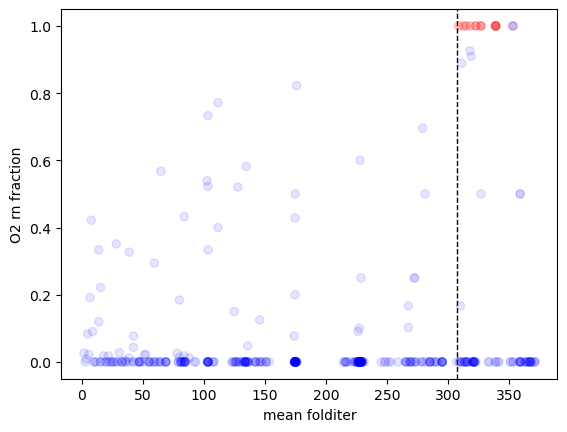

SAM (0.0732854527648617, '1.454728e-01')


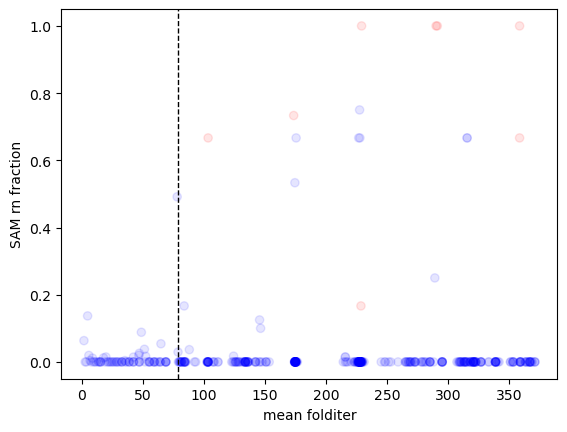

ATP (-0.014093526063696439, '7.797960e-01')


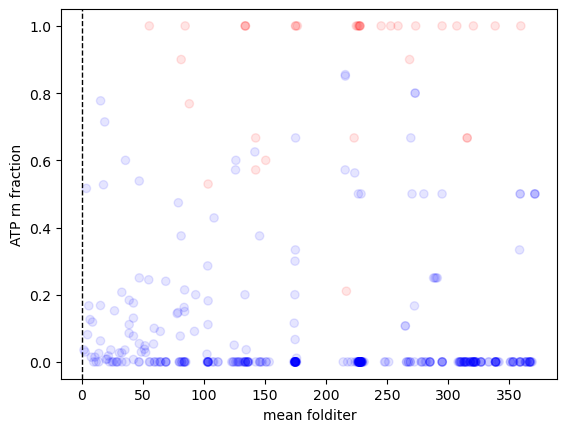

CoA (0.00793239151612862, '8.749642e-01')


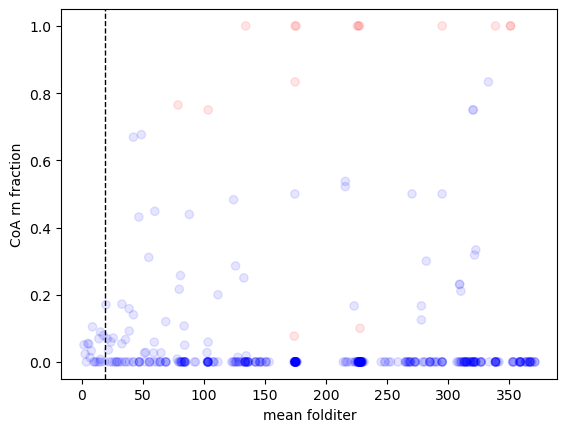

FAD (0.07302791314496608, '1.468967e-01')


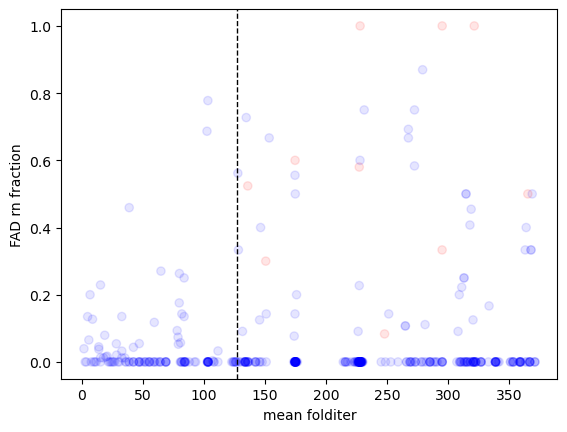

In [35]:
cofactorScatter('C00007', 'O2', x2rnFrac_O2_0, ETU_O2)
cofactorScatter('C00019', 'SAM', x2rnFrac_SAM_0, ETU_SAM)
cofactorScatter('C00002', 'ATP', x2rnFrac_ATP_0, ETU_ATP)
cofactorScatter('C00010', 'CoA', x2rnFrac_CoA_0, ETU_CoA)
cofactorScatter('C00016', 'FAD', x2rnFrac_FAD_0, ETU_FAD)

In [36]:
def getCategories(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc):
    emerge_to_use = set()  
    learn_to_use = set()
    unclassified = set()
    
    never_use_direct = set() # direct/total == 0
    never_use = set()  # direct/total == 0; indirect/total == 0; 'orthogonal'
    indirect_use = set() # direct/total == 0; indirect/total > 0

    for x, frac in x2rnFrac_cofactor_0.items():  # direct/total
        if frac == 0:
             never_use_direct.add(x)
        else:
            if x in etu:
                emerge_to_use.add(x)
            elif x in unc:
                unclassified.add(x)
            else:
                learn_to_use.add(x)  # here we don't check the direction...
    
    for x, frac in x2rnFrac_cofactor_1.items():  # indirect/total
        if x in never_use_direct and frac == 0:
             never_use.add(x)
        else:
            indirect_use.add(x)
    
    indirect_use_only = indirect_use - (emerge_to_use|learn_to_use|unclassified)
    return never_use, indirect_use_only, emerge_to_use, unclassified, learn_to_use

In [37]:
def getCategories_using(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc, using):
    
    emerge_to_use = set()  
    learn_to_use = set()
    unclassified = set()
    
    never_use_direct = set() # direct/total == 0
    never_use = set()  # direct/total == 0; indirect/total == 0; 'orthogonal'
    indirect_use = set() # direct/total == 0; indirect/total > 0

    for x, frac in x2rnFrac_cofactor_0.items():  # direct/total
        if frac == 0:
             never_use_direct.add(x)
        else:
            if x in etu:
                emerge_to_use.add(x)
            elif x in unc:
                unclassified.add(x)
            else:
                # x has using rn
                if len(set(x2rn_scope[x]) & set(using)) != 0:
                    learn_to_use.add(x)
                # producing only
                else:
                    indirect_use.add(x)
                
    
    for x, frac in x2rnFrac_cofactor_1.items():  # indirect/total
        if x in never_use_direct and frac == 0:
             never_use.add(x)
        else:
            indirect_use.add(x)
    
    indirect_use_only = indirect_use - (emerge_to_use|learn_to_use|unclassified)
    return never_use, indirect_use_only, emerge_to_use, unclassified, learn_to_use

In [38]:
def drawPie(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc, title):
    never_use, indirect_use, emerge_to_use, unclassified, learn_to_use = getCategories(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc)
    
    labels = ['never_use', 'indirect_use', 'learn_to_use', 'unclassified', 'emerge_to_use']
    values = [len(never_use), len(indirect_use), len(learn_to_use), len(unclassified), len(emerge_to_use)]
    colors = ['gray', 'lightgray', 'lightblue', '#f94449', 'red']
#     hatches = ['', '', '', '.', '']

    fig, ax = plt.subplots(figsize=(4, 4))
    wedges, texts, autotexts = ax.pie(values, colors=colors, autopct=lambda p: '{:.0f}% ({:.0f})'.format(p, p * sum(values) / 100), startangle=90, labeldistance=1.05)
    plt.title(f'{title} n={sum(values)}')
    # plt.savefig(f'piechart_cofactor_{title}.svg', dpi=300, bbox_inches='tight')
    plt.show()

In [39]:
def drawPie_using(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc, title, using):
    never_use, indirect_use, emerge_to_use, unclassified, learn_to_use = getCategories_using(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc, using)
    
    labels = ['never_use', 'indirect_use', 'learn_to_use', 'unclassified', 'emerge_to_use']
    values = [len(never_use), len(indirect_use), len(learn_to_use), len(unclassified), len(emerge_to_use)]
    colors = ['gray', 'lightgray', 'lightblue', '#f94449', 'red']
#     hatches = ['', '', '', '.', '']

    fig, ax = plt.subplots(figsize=(4, 4))
    wedges, texts, autotexts = ax.pie(values, colors=colors, autopct=lambda p: '{:.0f}% ({:.0f})'.format(p, p * sum(values) / 100), startangle=90, labeldistance=1.05)
    plt.title(f'{title} n={sum(values)}')
    # plt.savefig(f'piechart_cofactor_{title}.svg', dpi=300, bbox_inches='tight')
    plt.show()

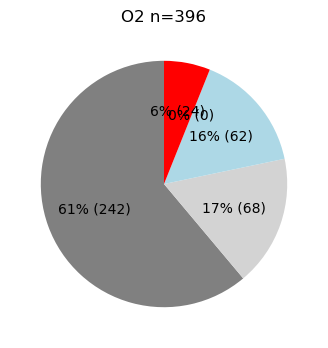

In [40]:
drawPie_using(x2rnFrac_O2_0, x2rnFrac_O2_1, ETU_O2, UC_O2, 'O2', using)
# drawPie(x2rnFrac_ATP_0, x2rnFrac_ATP_1, ETU_ATP, UC_ATP, 'ATP')
# drawPie(x2rnFrac_SAM_0, x2rnFrac_SAM_1, ETU_SAM, UC_SAM, 'SAM')
# drawPie(x2rnFrac_CoA_0, x2rnFrac_CoA_1, ETU_CoA, UC_CoA, 'CoA')
# drawPie(x2rnFrac_FAD_0, x2rnFrac_FAD_1, ETU_FAD, UC_FAD, 'FAD')

### stackplots instead

In [41]:
# Define categories, values, and colors
categories = ['never_use', 'indirect_use', 'emerge_to_use', 'unclassified', 'learn_to_use']
colors = ['gray', 'skyblue', 'red', '#f94449', 'pink']

In [42]:
NU_O2, IU_O2, ETU_O2, UC_O2, LTU_O2 =getCategories_using(x2rnFrac_O2_0, x2rnFrac_O2_1, ETU_O2, UC_O2, using)
NU_ATP, IU_ATP, ETU_ATP, UC_ATP, LTU_ATP =getCategories(x2rnFrac_ATP_0, x2rnFrac_ATP_1, ETU_ATP, UC_ATP)
NU_SAM, IU_SAM, ETU_SAM, UC_SAM, LTU_SAM =getCategories(x2rnFrac_SAM_0, x2rnFrac_SAM_1, ETU_SAM, UC_SAM)
NU_CoA, IU_CoA, ETU_CoA, UC_CoA, LTU_CoA =getCategories(x2rnFrac_CoA_0, x2rnFrac_CoA_1, ETU_CoA, UC_CoA)
NU_FAD, IU_FAD, ETU_FAD, UC_FAD, LTU_FAD =getCategories(x2rnFrac_FAD_0, x2rnFrac_FAD_1, ETU_FAD, UC_FAD)

NU_NAD, IU_NAD, ETU_NAD, UC_NAD, LTU_NAD =getCategories(x2rnFrac_NAD_0, x2rnFrac_NAD_1, ETU_NAD, UC_NAD)
NU_NADP, IU_NADP, ETU_NADP, UC_NADP, LTU_NADP =getCategories(x2rnFrac_NADP_0, x2rnFrac_NADP_1, ETU_NADP, UC_NADP)
NU_PLP, IU_PLP, ETU_PLP, UC_PLP, LTU_PLP =getCategories(x2rnFrac_PLP_0, x2rnFrac_PLP_1, ETU_PLP, UC_PLP)
NU_ThDP, IU_ThDP, ETU_ThDP, UC_ThDP, LTU_ThDP =getCategories(x2rnFrac_ThDP_0, x2rnFrac_ThDP_1, ETU_ThDP, UC_ThDP)

NU_IPP, IU_IPP, ETU_IPP, UC_IPP, LTU_IPP =getCategories(x2rnFrac_IPP_0, x2rnFrac_IPP_1, ETU_IPP, UC_IPP)
NU_FMN, IU_FMN, ETU_FMN, UC_FMN, LTU_FMN =getCategories(x2rnFrac_FMN_0, x2rnFrac_FMN_1, ETU_FMN, UC_FMN)
NU_Cobalamin, IU_Cobalamin, ETU_Cobalamin, UC_Cobalamin, LTU_Cobalamin =getCategories(x2rnFrac_Cobalamin_0, x2rnFrac_Cobalamin_1, ETU_Cobalamin, UC_Cobalamin)
NU_AcetylCoA, IU_AcetylCoA, ETU_AcetylCoA, UC_AcetylCoA, LTU_AcetylCoA =getCategories(x2rnFrac_AcetylCoA_0, x2rnFrac_AcetylCoA_1, ETU_AcetylCoA, UC_AcetylCoA)

In [43]:
print('    ETU   LTU   UC ')
print('------------------------')

print('O2  ', len(ETU_O2), '  ', len(LTU_O2), '  ', len(UC_O2))
print('ATP ', len(ETU_ATP), '  ', len(LTU_ATP), '  ', len(UC_ATP))
print('CoA  ', len(ETU_CoA), '  ', len(LTU_CoA), '  ', len(UC_CoA))
print('SAM ', len(ETU_SAM), '  ', len(LTU_SAM), '  ', len(UC_SAM))
print('FAD ', len(ETU_FAD), '  ', len(LTU_FAD), '  ', len(UC_FAD))
print('NAD ', len(ETU_NAD), '  ', len(LTU_NAD), '  ', len(UC_NAD))
print('NADP', len(ETU_NADP), '  ', len(LTU_NADP), '  ', len(UC_NADP))
print('PLP ', len(ETU_PLP), '  ', len(LTU_PLP), '  ', len(UC_PLP))
print('ThDP ', len(ETU_ThDP), '  ', len(LTU_ThDP), '  ', len(UC_ThDP))

    ETU   LTU   UC 
------------------------
O2   24    62    0
ATP  34    95    3
CoA   15    62    2
SAM  8    32    0
FAD  10    79    0
NAD  12    114    1
NADP 14    104    2
PLP  8    33    0
ThDP  2    20    0


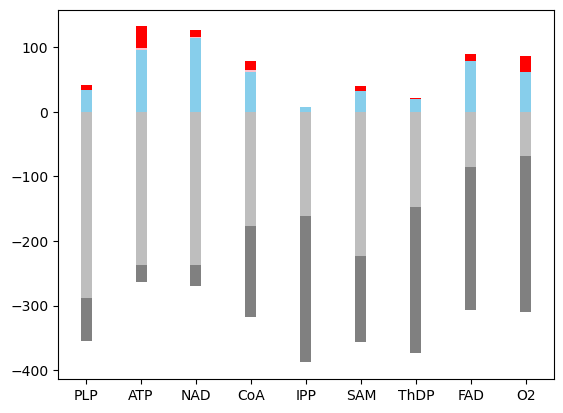

In [44]:
# a = [-len(IU_PLP), -len(IU_ATP), -len(IU_NAD), -len(IU_NADP), -len(IU_CoA), -len(IU_AcetylCoA), -len(IU_IPP), -len(IU_SAM), -len(IU_ThDP), -len(IU_FAD), -len(IU_FMN), -len(IU_Cobalamin), -len(IU_O2)] 
# b = [-len(NU_PLP), -len(NU_ATP), -len(NU_NAD), -len(NU_NADP), -len(NU_CoA), -len(NU_AcetylCoA), -len(NU_IPP), -len(NU_SAM), -len(NU_ThDP), -len(NU_FAD),  -len(NU_FMN), -len(NU_Cobalamin), -len(NU_O2)]  
# c = [len(LTU_PLP), len(LTU_ATP), len(LTU_NAD), len(LTU_NADP), len(LTU_CoA), len(LTU_AcetylCoA), len(LTU_IPP), len(LTU_SAM), len(LTU_ThDP), len(LTU_FAD), len(LTU_FMN),  len(LTU_Cobalamin), len(LTU_O2)]
# d = [len(UC_PLP), len(UC_ATP), len(UC_NAD), len(UC_NADP), len(UC_CoA), len(UC_AcetylCoA), len(UC_IPP), len(UC_SAM), len(UC_ThDP), len(UC_FAD), len(UC_FMN), len(UC_Cobalamin), len(UC_O2)]
# e = [len(ETU_PLP), len(ETU_ATP), len(ETU_NAD), len(ETU_NADP), len(ETU_CoA), len(ETU_AcetylCoA), len(ETU_IPP), len(ETU_SAM), len(ETU_ThDP), len(ETU_FAD), len(ETU_FMN),  len(ETU_Cobalamin), len(ETU_O2)]

a = [-len(IU_PLP), -len(IU_ATP), -len(IU_NAD), -len(IU_CoA), -len(IU_IPP), -len(IU_SAM), -len(IU_ThDP), -len(IU_FAD), -len(IU_O2)] 
b = [-len(NU_PLP), -len(NU_ATP), -len(NU_NAD), -len(NU_CoA), -len(NU_IPP), -len(NU_SAM), -len(NU_ThDP), -len(NU_FAD), -len(NU_O2)]  
c = [len(LTU_PLP), len(LTU_ATP), len(LTU_NAD), len(LTU_CoA), len(LTU_IPP), len(LTU_SAM), len(LTU_ThDP), len(LTU_FAD), len(LTU_O2)]
d = [len(UC_PLP), len(UC_ATP), len(UC_NAD), len(UC_CoA), len(UC_IPP), len(UC_SAM), len(UC_ThDP), len(UC_FAD), len(UC_O2)]
e = [len(ETU_PLP), len(ETU_ATP), len(ETU_NAD), len(ETU_CoA), len(ETU_IPP), len(ETU_SAM), len(ETU_ThDP), len(ETU_FAD), len(ETU_O2)]


data = np.array([a, b, c, d, e])
# data = np.array([a, c, d, e])
data_shape = np.shape(data)

# Take negative and positive data apart and cumulate
def get_cumulated_array(data, **kwargs):
    cum = data.clip(**kwargs)
    cum = np.cumsum(cum, axis=0)
    d = np.zeros(np.shape(data))
    d[1:] = cum[:-1]
    return d  

cumulated_data = get_cumulated_array(data, min=0)
cumulated_data_neg = get_cumulated_array(data, max=0)

# Re-merge negative and positive data.
row_mask = (data<0)
cumulated_data[row_mask] = cumulated_data_neg[row_mask]
data_stack = cumulated_data

cols = ["#bebebe", "gray", "skyblue", "pink", 'red']
# cols = ["skyblue", "pink", "orange", 'red']

fig = plt.figure()
ax = plt.subplot(111)

bar_width = 0.2  # Adjust this value to make the bars narrower

for i in np.arange(0, data_shape[0]):
    ax.bar(np.arange(data_shape[1]), data[i], bottom=data_stack[i], color=cols[i], width=bar_width)

# Custom x-axis labels
# x_labels = ['PLP', 'ATP', 'NAD', 'NADP', 'CoA', 'A-CoA', 'IPP', 'SAM', 'ThDP', 'FAD', 'FMN', 'Cobalamin', 'O2']  # Replace with your custom labels
x_labels = ['PLP', 'ATP', 'NAD', 'CoA', 'IPP', 'SAM', 'ThDP', 'FAD', 'O2']  # Replace with your custom labels
ax.set_xticks(np.arange(data_shape[1]))
ax.set_xticklabels(x_labels)

# plt.savefig('cofactor_stacked_bars.svg', dpi=300, bbox_inches='tight')
# plt.savefig('cofactor_stacked_bars_no_neveruse.svg', dpi=300, bbox_inches='tight')
plt.show()

### look for all cpds for high-ETU/LTU cpds

In [45]:
# this takes a while if you use getETU_UC_using

# cpd2ETUlineages = {}
# cpd2LTUlineages = {}
# for cpd in result.scope.cpds:  # for all compounds discovered in our simulation
#     print(len(cpd2ETUlineages), cpd)  # log for progress
    
#     # get direct cpd-using reactions within scope
#     direct_cofactor_rn_set = getDirectRns(cpd) & set(result.scope.rns)  
    
#     # get ETU lineages
#     if cpd.startswith('C'):
#         ETU, UC = getETU_UC_using(cpd, direct_cofactor_rn_set)  # excludes cofactor-producing rns

#         # redefine direct_cofactor_rn_set to exclude cofactor-producing rns
#         run = '87452'
#         using, both, producing = getUsingProducingRns(run, cpd, direct_cofactor_rn_set)
#         direct_cofactor_rn_set = set(using) | set(both.keys())
#     else:  # Z cpds
#         ETU, UC = getETU_UC_direct(direct_cofactor_rn_set)
#     cpd2ETUlineages[cpd] = ETU

#     # get LTU lineages
#     directLineages = set()
#     for x, rns in x2rn_scope.items():  # check each lineage and their reactions
#         for rn in rns:
#             if rn in direct_cofactor_rn_set:  # using or both, not produce
#                 directLineages.add(x)
#                 break
#     cpd2LTUlineages[cpd] = directLineages - ETU  # includes UC

# dict2csv(cpd2ETUlineages, '../data/assets/cpd2ETUlineages_preATP_getETU_UC_using_strict.csv')
# dict2csv(cpd2LTUlineages, '../data/assets/cpd2LTUlineages_preATP_getETU_UC_using_strict.csv')

In [46]:
cpd2ETUlineages = csv2dict('../data/assets/cpd2ETUlineages_preATP_getETU_UC_using_strict.csv')
cpd2LTUlineages = csv2dict('../data/assets/cpd2LTUlineages_preATP_getETU_UC_using_strict.csv')

cpd2ETUlineagesNum = {k:len(v) for k,v in cpd2ETUlineages.items()}
cpd2LTUlineagesNum = {k:len(v) for k,v in cpd2LTUlineages.items()}

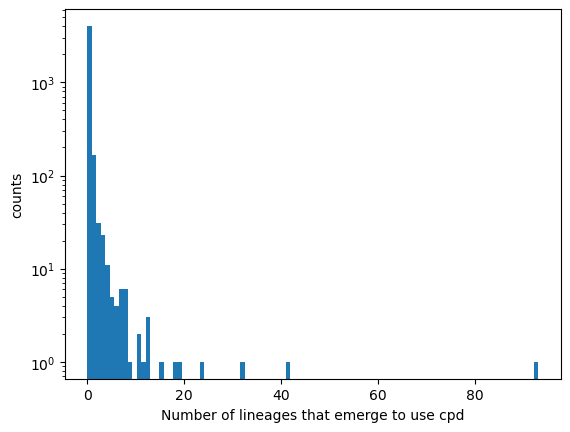

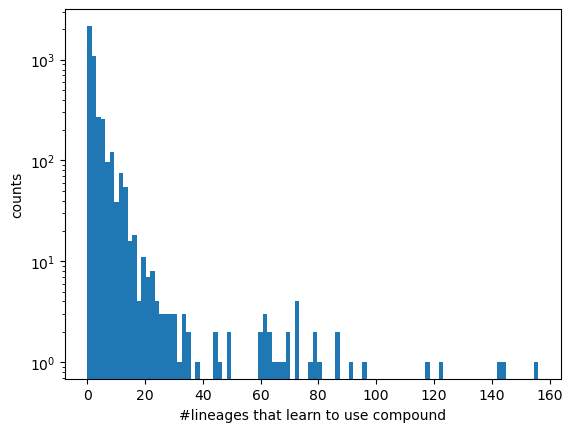

In [47]:
histogram(cpd2ETUlineagesNum, bins=100, x_axis='Number of lineages that emerge to use cpd', ylog=True)
histogram(cpd2LTUlineagesNum, bins=100, x_axis='#lineages that learn to use compound', ylog=True)

In [48]:
cpd2LTUlineagesNum['C00007']

62

In [49]:
for k,v in cpd2ETUlineagesNum.items():
    if v > 10:
        print(k, cpd2name[k], v)

C00009 Orthophosphate 13
C00005 NADPH 11
Z00015 Iron 15
C00080 H+ 41
C00011 CO2 18
C00002 ATP 32
C00008 ADP 19
C00001 H2O 93
Z00025 Heme 12
Z00029 Mg 13
Z00054 Zinc 11
C00007 Oxygen 24
C00013 Diphosphate 13


In [50]:
# top LTU cpds
{(cpd2name.get(k, 'no name'), k): v for k, v in sorted(cpd2LTUlineagesNum.items(), key=lambda item: item[1], reverse=True)}

{('Mg', 'Z00029'): 156,
 ('H2O', 'C00001'): 145,
 ('Mn', 'Z00030'): 143,
 ('H+', 'C00080'): 123,
 ('Zinc', 'Z00054'): 117,
 ('ATP', 'C00002'): 96,
 ('Iron', 'Z00015'): 91,
 ('NADPH', 'C00005'): 87,
 ('NADH', 'C00004'): 87,
 ('NAD+', 'C00003'): 81,
 ('NADP+', 'C00006'): 79,
 ('FAD', 'Z00013'): 78,
 ('CO2', 'C00011'): 77,
 ('Orthophosphate', 'C00009'): 73,
 ('Flavoprotein', 'Z00019'): 72,
 ('Divalent Metal (M2)', 'Z00069'): 72,
 ('Cobalt', 'Z00006'): 72,
 ('Calcium', 'Z00055'): 70,
 ('ADP', 'C00008'): 70,
 ('4Fe4S', 'Z00002'): 68,
 ('NAD/NADP', 'Z00032'): 67,
 ('CoA', 'C00010'): 64,
 ('Ammonia', 'C00014'): 63,
 ('Diphosphate', 'C00013'): 63,
 ('FMN', 'Z00014'): 62,
 ('Oxygen', 'C00007'): 62,
 ('Generic FeS', 'Z00063'): 61,
 ('AMP', 'C00020'): 60,
 ('Acetyl-CoA', 'C00024'): 60,
 ('Reduced ferredoxin', 'C00138'): 49,
 ('Nickel', 'Z00034'): 49,
 ('Heme', 'Z00025'): 46,
 ('L-Glutamate', 'C00025'): 44,
 ('Oxidized ferredoxin', 'C00139'): 44,
 ('Acceptor', 'C00028'): 38,
 ('GTP', 'C00044'): 35

In [51]:
# for 93% of cpd, they have ZERO lineages that ETU that cpd

print(list(cpd2ETUlineagesNum.values()).count(0))
print(list(cpd2ETUlineagesNum.values()).count(0)/len(cpd2ETUlineagesNum))

4026
0.9375873311597578


In [52]:
# top ETU cpds
{(cpd2name.get(k, 'no name'), k): v for k, v in sorted(cpd2ETUlineagesNum.items(), key=lambda item: item[1], reverse=True)}

{('H2O', 'C00001'): 93,
 ('H+', 'C00080'): 41,
 ('ATP', 'C00002'): 32,
 ('Oxygen', 'C00007'): 24,
 ('ADP', 'C00008'): 19,
 ('CO2', 'C00011'): 18,
 ('Iron', 'Z00015'): 15,
 ('Orthophosphate', 'C00009'): 13,
 ('Mg', 'Z00029'): 13,
 ('Diphosphate', 'C00013'): 13,
 ('Heme', 'Z00025'): 12,
 ('NADPH', 'C00005'): 11,
 ('Zinc', 'Z00054'): 11,
 ('Nickel', 'Z00034'): 9,
 ('PLP', 'Z00035'): 8,
 ('4Fe4S', 'Z00002'): 8,
 ('Generic FeS', 'Z00063'): 8,
 ('NADH', 'C00004'): 8,
 ('CoA', 'C00010'): 8,
 ('NAD+', 'C00003'): 8,
 ('FAD', 'Z00013'): 7,
 ('Ammonia', 'C00014'): 7,
 ('Hydrogen', 'C00282'): 7,
 ('NADP+', 'C00006'): 7,
 ('Oxidized ferredoxin', 'C00139'): 7,
 ('Reduced ferredoxin', 'C00138'): 7,
 ('AMP', 'C00020'): 6,
 ('L-Glutamate', 'C00025'): 6,
 ('Cobalamin', 'Z00009'): 6,
 ('S-Adenosyl-L-methionine', 'C00019'): 6,
 ('Reduced acceptor', 'C00030'): 5,
 ('Coenzyme F420', 'C00876'): 5,
 ('Formate', 'C00058'): 5,
 ('Flavoprotein', 'Z00019'): 5,
 ('L-Serine', 'C00065'): 5,
 ('Thioredoxin', 'C00342'

In [53]:
# compare ETU with LTU

# bokeh plot:
remove = ['C00001', 'C00080']  # remove H2O and H+
d1 = {k:v for k,v in cpd2ETUlineagesNum.items() if k not in remove}
d2 = {k:v for k,v in cpd2LTUlineagesNum.items() if k not in remove}

p = figure(width=800, height=800)

# Add annotations
valid_keys, data1, data2 = todata(d1, d2)

source = {'x': data1, 'y': data2, 'label': [f"{cpd2name.get(key, 'no name')}" for key in valid_keys]}
p.scatter('x', 'y', source=source, size=10, alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = '#ETU lineages'
p.yaxis.axis_label = '#LTU lineages'
# p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [54]:
cpd2ETUlineagesNum['C00007']/cpd2LTUlineagesNum['C00007']

0.3870967741935484

In [55]:
# outlier
cpd2ETUlineagesNum['C02999'], cpd2LTUlineagesNum['C02999']

(3, 1)

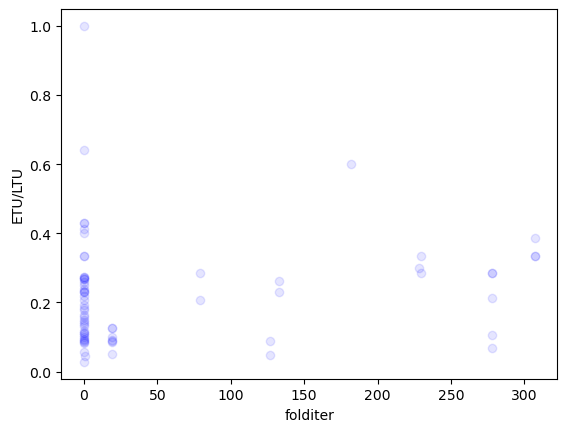

In [56]:
# ratio instead
# more ETU -> more emergence than recruitment
# more LTU -> more recruitment than emergence

cpd2ratio = {}
for c, v in cpd2ETUlineagesNum.items():
    if v > 2 and c != 'C02999':  # only highly influential cpds
        if cpd2LTUlineagesNum[c] != 0:
            cpd2ratio[c] = cpd2ETUlineagesNum[c]/cpd2LTUlineagesNum[c]
        else:
            print(c, cpd2name[c])

scatter(cpd2foMean, cpd2ratio, x_axis='folditer', y_axis='ETU/LTU')

In [57]:
d1 = cpd2foMean
d2 = cpd2ratio

p = figure(width=800, height=800)

# Add annotations
valid_keys, data1, data2 = todata(d1, d2)

source = {'x': data1, 'y': data2, 'label': [f"{cpd2name.get(key, 'no name')}" for key in valid_keys]}
p.scatter('x', 'y', source=source, size=10, alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'iter'
p.yaxis.axis_label = 'ETU/LTU'
# p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

# 3. lineage reuse timing

## x2usage (mean, std) across 1000 runs of ATP pre-expansion

In [58]:
# # this takes a while

# run2x2usage = {}
# for run in df_folds_folditer.columns:

#     rule2fo = {}
#     for key, value in df_rules_folditer[run].items():
#         if eval(key)[1] not in rule2fo.keys():
#             rule2fo[eval(key)[1]] = [value]
#         else:
#             rule2fo[eval(key)[1]].append(value)
    
#     folditer2rules = {}
#     for key, values in rule2fo.items():
#         for value in values:
#             if value not in folditer2rules.keys():
#                 folditer2rules[value] = [key]
#             else:
#                 folditer2rules[value].append(key)
            
#     x2usage = {x:set() for x in df_folds_folditer[run].keys()}  # empty dict
    
#     for i, rules in folditer2rules.items():
#         for rule in rules:
#             for x in rule:
#                 x2usage[x].add(i)  # don't record multiple usage within one fold_iter
#     x2usage.pop('fold_independent')
#     x2usage.pop('spontaneous')
    
#     run2x2usage[run] = x2usage

# with open('../data/assets/run2x2usage.pkl', 'wb') as file:
#     pickle.dump(run2x2usage, file)

In [59]:
run2x2usage = pd.read_pickle('../data/assets/run2x2usage.pkl')

In [60]:
x2foMean_od = dict(sorted(x2foMean.items(), key=lambda item: item[1]))
x2usageNum_1000 = {k:[] for k in x2foMean_od.keys()}  # enforce mean order

for x2usage in run2x2usage.values():
    for x, usage in x2usage.items():
        x2usageNum_1000[x].append(len(usage))

In [61]:
def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis', savefig=False):
    fig, ax = plt.subplots()
    
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)

    if savefig:
        plt.savefig(f'scatter_{x_axis}_{y_axis}.png', dpi=300, bbox_inches='tight')
    
    plt.show()

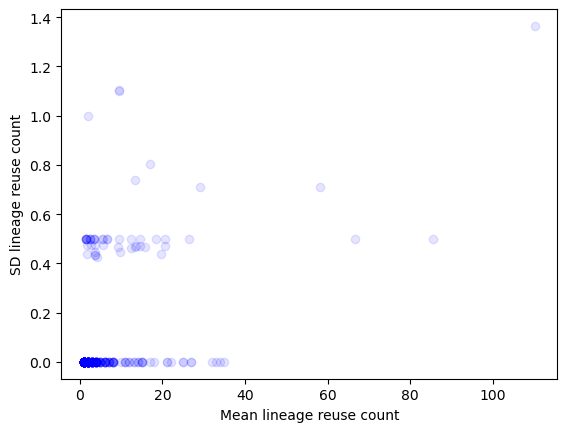

In [62]:
x2usageNum_Mean = {k:np.mean(v) for k,v in x2usageNum_1000.items()}
x2usageNum_Std = {k:np.std(v) for k,v in x2usageNum_1000.items()}

scatter(x2usageNum_Mean, x2usageNum_Std, 'Mean lineage reuse count', 'SD lineage reuse count', savefig=False)

In [63]:
p = figure(width=400, height=300)

# define data
d1 = x2usageNum_Mean
d2 = x2usageNum_Std

valid_keys, data1, data2 = todata(d1, d2)
# data2 = np.log10(data2)
labels = [x2name.get(key, key) for key in valid_keys]
# colors = [class2color2[x2class[k]] for k in valid_keys]

# source
source = ColumnDataSource(data={
    'x': data1,
    'y': data2,
    'label': labels
})

p.scatter('x', 'y', source=source, size=10, alpha=0.5, line_color=None)
# p.scatter('x', 'y', source=source, size=10, alpha=1, line_color=None, fill_color='color')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("X", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'Mean'
p.yaxis.axis_label = 'Std'
# p.xaxis.ticker = [0, 50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# output_file("scatter.html")
show(p)

### cpd2reuseNum

In [64]:
run2fo2reuseNum = {}
for run, x2usage in run2x2usage.items():
    fo2lineagesUsed = {}
    for x, usage in x2usage.items():
        for fo in usage:
            if fo not in fo2lineagesUsed:
                fo2lineagesUsed[fo] = set([x])
            else:
                fo2lineagesUsed[fo].add(x) 
    fo2lineagesUsedNum = {fo:len(lineagesUsed) for fo, lineagesUsed in fo2lineagesUsed.items()}
    
    fo2lineagesUsedNum_Full = {}
    for i in range(0, max(fo2lineagesUsedNum.keys())+1):
        if i not in fo2lineagesUsedNum.keys():
            fo2lineagesUsedNum_Full[i] = 0
        else:
            fo2lineagesUsedNum_Full[i] = fo2lineagesUsedNum[i]

    run2fo2reuseNum[run] = fo2lineagesUsedNum_Full

In [65]:
# FAD, SAM, chorismate, phylloquinone, oxygen
innovation2reuse = {'C00016': [], 'C00019': [], 'C00251': [], 'C02059': [], 'C00007': []}
for c in innovation2reuse.keys():
    for run, i in df_cpds_folditer.loc[c].items():
        innovation2reuse[c].append(run2fo2reuseNum[run][i])

In [66]:
innovation2reuse['C00007']

[99,
 98,
 100,
 98,
 100,
 100,
 99,
 99,
 98,
 98,
 100,
 100,
 98,
 98,
 100,
 100,
 99,
 98,
 98,
 100,
 100,
 98,
 98,
 98,
 99,
 98,
 99,
 100,
 100,
 100,
 99,
 99,
 98,
 98,
 99,
 98,
 99,
 100,
 98,
 98,
 100,
 99,
 100,
 98,
 98,
 98,
 100,
 100,
 98,
 98,
 100,
 98,
 100,
 99,
 100,
 98,
 98,
 98,
 100,
 99,
 98,
 99,
 98,
 98,
 100,
 99,
 98,
 100,
 99,
 98,
 100,
 100,
 99,
 98,
 99,
 98,
 100,
 100,
 99,
 100,
 98,
 100,
 98,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 98,
 98,
 100,
 99,
 100,
 98,
 99,
 98,
 100,
 99,
 100,
 99,
 99,
 98,
 100,
 100,
 100,
 98,
 100,
 98,
 99,
 100,
 98,
 98,
 100,
 98,
 100,
 99,
 100,
 100,
 98,
 98,
 99,
 99,
 99,
 99,
 100,
 99,
 98,
 100,
 100,
 98,
 99,
 100,
 99,
 98,
 99,
 100,
 100,
 100,
 98,
 99,
 100,
 100,
 100,
 98,
 100,
 98,
 99,
 100,
 100,
 99,
 98,
 100,
 100,
 100,
 100,
 98,
 98,
 99,
 99,
 98,
 99,
 98,
 100,
 100,
 100,
 100,
 98,
 98,
 100,
 99,
 99,
 99,
 98,
 100,
 99,
 100,
 99,
 99,
 100,
 98,
 98,
 98,


In [67]:
from collections import defaultdict

cpd2reuse = defaultdict(list)
for c in df_cpds_folditer.index:
    for run, i in df_cpds_folditer.loc[c].items():
        cpd2reuse[c].append(run2fo2reuseNum[run][i])

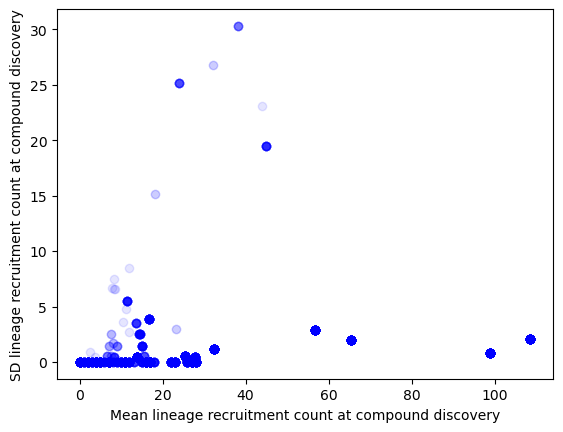

In [68]:
cpd2reuse_Mean = {k:np.mean(v) for k,v in cpd2reuse.items()}
cpd2reuse_Std = {k:np.std(v) for k,v in cpd2reuse.items()}

scatter(cpd2reuse_Mean, cpd2reuse_Std, 'Mean lineage recruitment count at compound discovery', 'SD lineage recruitment count at compound discovery', savefig=False)

In [69]:
p = figure(width=400, height=300)

# define data
d1 = cpd2reuse_Mean
d2 = cpd2reuse_Std

valid_keys, data1, data2 = todata(d1, d2)
# data2 = np.log10(data2)
labels = [cpd2name.get(key, key) for key in valid_keys]
# colors = ['red' if k in evo else 'blue' for k in valid_keys]

# source
source = ColumnDataSource(data={
    'x': data1,
    'y': data2,
    'label': labels
})

p.scatter('x', 'y', source=source, size=10, alpha=0.5, line_color=None)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'Mean'
p.yaxis.axis_label = 'Std'
# p.xaxis.ticker = [0, 50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# output_file("scatter.html")
show(p)

## rn2ec

In [70]:
rn2ec = csv2dict('../data/assets/rn2ec.csv')

In [71]:
x2rn_ec1 = {}
x2rn_ec2 = {}
for x, rns in x2rn.items():
    ec_list1 = []
    ec_list2 = []
    for rn in rns:
        if rn2ec.get(rn[:6], 0) == 0:  # not in rn2ec
            ec_list1.append('0')
        else:
            ec_list1.append(rn2ec[rn[:6]].split('.')[0])
            ec_list2.append(rn2ec[rn[:6]].split('.')[0] + '.' + rn2ec[rn[:6]].split('.')[1])
    x2rn_ec1[x] = ec_list1
    x2rn_ec2[x] = ec_list2

## x2usage from fastest run

In [72]:
# fastest run
result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-09-27_13-49-38_no_lookahead_preExpansion_C00002_37860.pkl.gz')

In [73]:
rule2fo = {}
for key, value in result.rules_folditer.items():
    if key[1] not in rule2fo.keys():
        rule2fo[key[1]] = [value]
    else:
        rule2fo[key[1]].append(value)

folditer2rules = {}
for key , values in rule2fo.items():
    for value in values:
        if value not in folditer2rules.keys():
            folditer2rules[value] = [key]
        else:
            folditer2rules[value].append(key)
        
x2usage = {x:set() for x in result.folds_folditer.keys()}  # empty dict
x2usage.pop('fold_independent')
x2usage.pop('spontaneous')

for i, rules in folditer2rules.items():
    for rule in rules:
        for x in rule:
            if x in x2usage: # ignore 'fold_independent' and 'spontaneous'
                x2usage[x].add(i)  # don't record multiple usage within one fold_iter
x2usage = {x:sorted(list(s)) for x,s in x2usage.items()}

In [74]:
folditer2reactionRules = {}
for key , fo in result.rules_folditer.items():
        if fo not in folditer2reactionRules.keys():
            folditer2reactionRules[fo] = [key]
        else:
            folditer2reactionRules[fo].append(key)
            
x2usage_ec1 = {x:[] for x in result.folds_folditer.keys()}  # empty dict
x2usage_ec1.pop('fold_independent')
x2usage_ec1.pop('spontaneous')
x2usage_ec2 = {x:[] for x in result.folds_folditer.keys()}  # empty dict
x2usage_ec2.pop('fold_independent')
x2usage_ec2.pop('spontaneous')

for i, rrs in folditer2reactionRules.items():
    for rr in rrs:
        for x in rr[1]:
            if x in x2usage_ec1: # ignore 'fold_independent' and 'spontaneous'
                x2usage_ec1[x].append([i, rn2ec.get(rr[0], '0.0')[0]])
                x2usage_ec2[x].append([i, rn2ec.get(rr[0], '0.0')[0:3]])

In [75]:
notinrn2ec = []
for rn in result.scope.rns:
    if rn[:6] not in rn2ec.keys():
        notinrn2ec.append(rn)
print(len(notinrn2ec), len(result.scope.rns), len(rn2ec.keys()))

1345 7678 9491


### detailed look at x2usage

In [76]:
x2usageNum_noSingle = {x:len(usage) for x, usage in x2usage.items() if len(usage) > 1}

In [77]:
for k,v in dict(sorted(x2usageNum_noSingle.items(), key=lambda item: item[1], reverse=True)).items():
    print(k, v, x2name.get(k,k))

2003 112 Rossmann-like
2002 86 TIM beta/alpha-barrel
2007 66 Flavodoxin-like
304 58 Alpha-beta plaits
2004 35 P-loop domains-like
1 34 cradle loop barrel
10 33 jelly-roll
206 32 206
11 30 Immunoglobulin-like beta-sandwich
2006 27 HAD domain-like
246 27 Carbon-nitrogen hydrolase-like
221 27 beta-Grasp
7524 25 7524
7577 25 7577
3016 22 3016
2484 21 Ribonuclease H-like
236 21 GroES-like
7579 21 7579
205 21 205
244 20 FAD-linked reductases, C-terminal domain-like
12 18 Glycosyl hydrolase domain-like
109 18 Repetitive alpha hairpins
298 17 FwdE/GAPDH domain-like
101 17 HTH
2005 15 HUP domain-like
2487 15 The "swivelling" beta/beta/alpha domains
2486 15 2486
325 15 alpha/beta-Hammerhead/Barrel-sandwich hybrid
301 15 Bacillus chorismate mutase-like
323 15 323
129 14 129
7581 14 7581
222 14 Thioesterase/thiol ester dehydrase-isomerase-like
213 14 Nat/Ivy
7512 14 7512
2011 13 Phosphorylase/hydrolase-like
5 13 beta-propeller-like
327 13 Alpha-lytic protease prodomain-like
217 13 FAD-binding doma

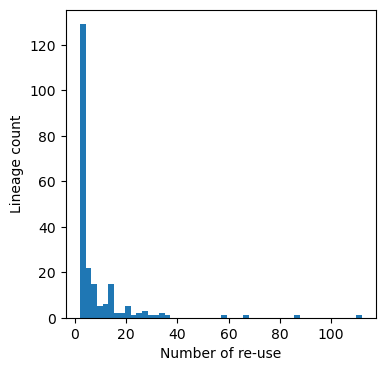

In [78]:
def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts', ylog=False, xlog=False):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.figure(figsize=(4, 4))
    
    plt.hist(data1, bins=bins, edgecolor=None)  # orientation='horizontal'
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)

    if ylog:
        plt.yscale('log', nonpositive='clip')
    if xlog:
        plt.xscale('log', nonpositive='clip')
    
    # plt.savefig('5A_inset.svg', dpi=300, bbox_inches='tight')
    plt.show()

histogram(x2usageNum_noSingle, bins=50, x_axis='Number of re-use', y_axis='Lineage count')

## duration (with new EC2 and new cofactor timing annotated)

In [79]:
x2usage_first_last = {key: [min(values), max(values)] for key, values in x2usage.items()}

In [80]:
# remove lineages with duration = 0
single_use_lineages = set()
x2usage_first_lastNoSingles = {}

for x , usage in x2usage_first_last.items():
    if usage[1]-usage[0] != 0:
        x2usage_first_lastNoSingles[x] = usage
    else:
        single_use_lineages.add(x)
print(len(single_use_lineages))

180


In [81]:
single_use_lineages & set(group1)

{'184', '253', '3997', '7544', '875'}

### lineages 'resurrected' by oxygen

In [82]:
# do not use oxygen at 296: 503, 5084, 219

# 211
# 281
# 209

In [83]:
lazarus = "211"
x2usage[lazarus], result.cpds_folditer['C00007']

([99, 296, 309], 296)

In [84]:
for rn in x2rn[lazarus]:
    if result.rns_folditer.get(rn, 'N/A') != 'N/A':
        print(rn, result.rns_folditer.get(rn, 'N/A'), 'C00007' in rn2cpds[rn], rn2rules[rn])

R05416 309 True {frozenset({'211'})}
R01507 296 True {frozenset({'211'})}
R02521_v1 296 True {frozenset({'211'})}
R08511_v1 88 False {frozenset({'2485', '109'}), frozenset({'211'}), frozenset({'3009'}), frozenset({'2485'})}
R06632_v1 296 True {frozenset({'211'})}
R01372_v1 296 True {frozenset({'211'})}
R02530_v3 99 False {frozenset({'211'})}
R00816_v1 296 True {frozenset({'211'})}
R04089_v1 296 True {frozenset({'211'})}
R05295_v1 296 True {frozenset({'211'})}
R05246_v1 296 True {frozenset({'211'})}
R02530_v1 99 False {frozenset({'211'})}
R05404_v1 296 True {frozenset({'211'})}
R02530_v2 99 False {frozenset({'211'})}
R05778_v1 296 True {frozenset({'211'})}


## dot per use

In [85]:
# remove single-use folds
x2usageNoSingles = {}
for x , usage in x2usage.items():
    if x in x2usage_first_lastNoSingles.keys():
        x2usageNoSingles[x] = usage
print(len(x2usage) - len(x2usageNoSingles))

x2usage_secondLast_last = {}
for key, values in x2usageNoSingles.items():
    x2usage_secondLast_last[key] = [sorted(values)[-2], sorted(values)[-1]]

180


<Figure size 1000x2000 with 0 Axes>

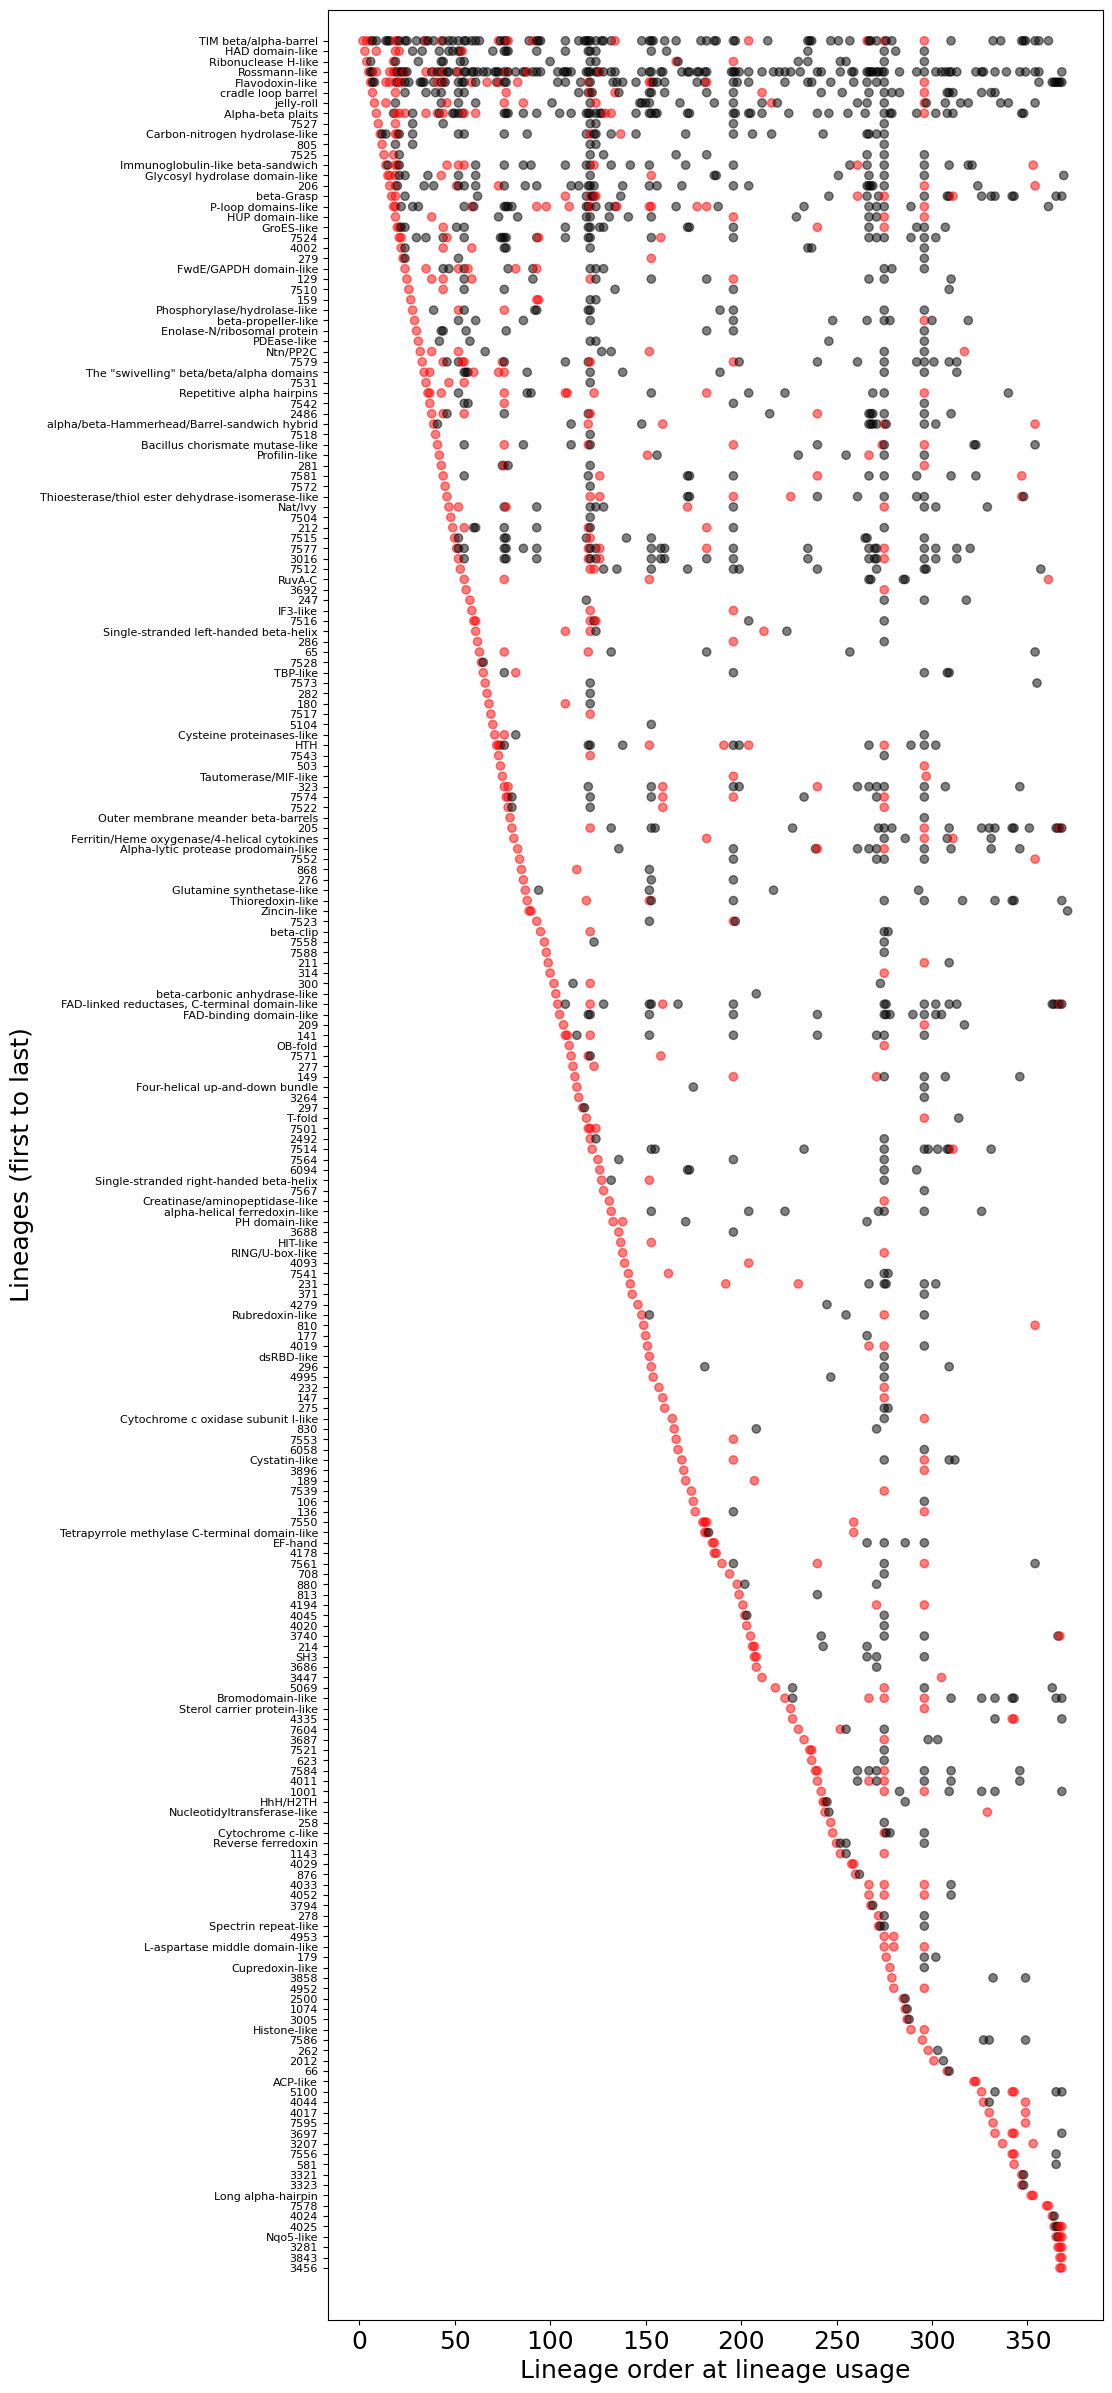

In [91]:
data = x2usageNoSingles
x2first_invention = {}
x2invention_iters = {}

# color by new ec invention
colors = []
for x in x2usageNoSingles.keys():
    # make fo2ec dict for lineage
    fo2ec = {}
    for fo_ec in x2usage_ec2[x]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    # track when inventions are made
    invention_fo = {}
    current_ecs = set()
    for fo, ecs in fo2ec.items():
        if ecs - current_ecs != set():  # first is red
        # if (ecs - current_ecs != set()) and (fo != result.folds_folditer[x]):  # first is black
            invention_fo[fo] = set(ecs - current_ecs)
        current_ecs = current_ecs | ecs
    # record first invention
    x2first_invention[x] = min(invention_fo.keys(), default=None)  # if no invention, return None
    # record invention iters
    x2invention_iters[x] = invention_fo

    # populate colors list
    for fo in fo2ec.keys():
        if fo in invention_fo.keys():
            colors.append('red')
        else:
            colors.append('black')


keys = list(data.keys())
values = [value for sublist in data.values() for value in sublist]
y_positions = [key for key, sublist in data.items() for _ in sublist]

# Plotting
plt.figure(figsize=(10, 20))
plt.figure(figsize=(10, 30))
plt.scatter(values, y_positions, marker='o', alpha=0.5, color=colors)
plt.gca().invert_yaxis()

# custom y labels
y_positions_list = []
for x in y_positions:
    if x not in y_positions_list:
        y_positions_list.append(x)
name_labels = [x2name.get(x, x) for x in keys]

# Adding labels
plt.xlabel('Lineage order at lineage usage', fontsize=18)
plt.ylabel('Lineages (first to last)', fontsize=18)
plt.yticks(ticks=y_positions_list, labels=name_labels, fontsize=8)
# plt.yticks([])
plt.ylim([220, -3])
plt.xticks(fontsize=18)

# plt.savefig('dot_per_use_2.png', dpi=300, bbox_inches='tight')
plt.show()

### time until first invention

In [87]:
x2time_until_invension = {}
no_invention_lineages = []
for x, first_invention in x2first_invention.items():
    if first_invention != None:
        x2time_until_invension[x] = first_invention - result.folds_folditer[x]
    else:
        no_invention_lineages.append(x)
len(x2first_invention), len(x2time_until_invension), len(no_invention_lineages)

(216, 152, 64)

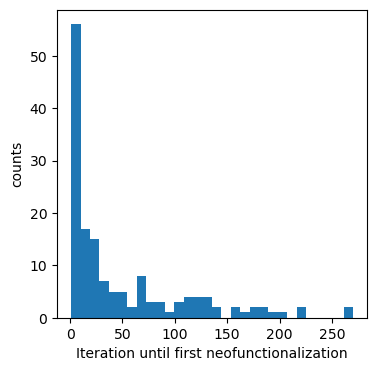

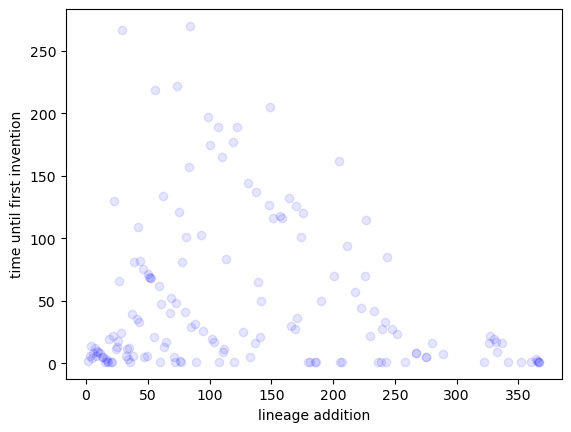

In [88]:
histogram(x2time_until_invension, bins=30, x_axis='Iteration until first neofunctionalization')
scatter(result.folds_folditer, x2time_until_invension, 'lineage addition', 'time until first invention')

In [89]:
len({k:v for k,v in x2time_until_invension.items() if v <= 30})

90

In [90]:
np.mean(list(x2time_until_invension.values()))

48.25657894736842

In [91]:
# bokeh plot:
d1 = result.folds_folditer
d2 = x2time_until_invension

p = figure(width=800, height=800)

# Add annotations
valid_keys, data1, data2 = todata(d1, d2)

source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in valid_keys],}
p.scatter('x', 'y', source=source, size=10, alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("X", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'lineage addition'
p.yaxis.axis_label = 'time until first invention'
# p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

### O2 neofunctionalization (catalyzing a novel 2-digit E.C.)

In [92]:
iter2inventionNum = {}
for x, invention_iters in x2invention_iters.items():
    for i in invention_iters:
        if i in iter2inventionNum:
            iter2inventionNum[i] += 1
        else:
            iter2inventionNum[i] = 1

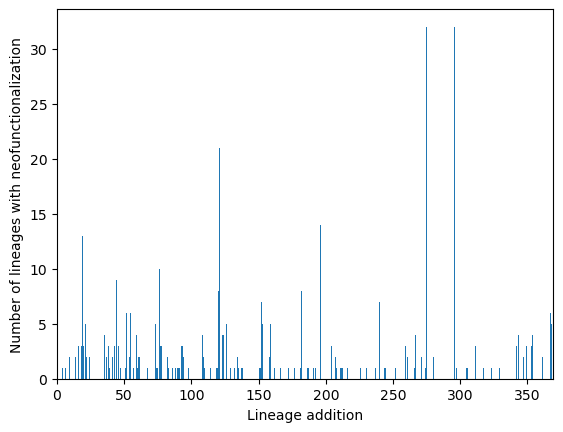

In [93]:
plt.bar(iter2inventionNum.keys(), iter2inventionNum.values())
plt.xlabel('Lineage addition')
plt.ylabel('Number of lineages with neofunctionalization')
plt.xlim([0, max(iter2inventionNum.keys())+1])
# plt.savefig(f'iter2neofunc.svg', dpi=300, bbox_inches='tight')
plt.show()

In [94]:
result.cpds_folditer['C00007']

296

## diversity

In [95]:
fo2lineagesUsed = {}
for x, usage in x2usage.items():
    for fo in usage:
        if fo not in fo2lineagesUsed:
            fo2lineagesUsed[fo] = set([x])
        else:
            fo2lineagesUsed[fo].add(x) 
fo2lineagesUsedNum = {fo:len(lineagesUsed) for fo, lineagesUsed in fo2lineagesUsed.items()}

fo2lineagesUsedNum_Full = {}
for i in range(0, max(fo2lineagesUsedNum.keys())+1):
    if i not in fo2lineagesUsedNum.keys():
        fo2lineagesUsedNum_Full[i] = 0
    else:
        fo2lineagesUsedNum_Full[i] = fo2lineagesUsedNum[i]
print(len(fo2lineagesUsedNum_Full))

372


In [96]:
folditer2cpd = {}
for c, order in result.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fo in folditer2cpd.keys():
    folditer2cpdNum[fo] = len(folditer2cpd[fo])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
print(len(folditer2cpdNumFull))

# only 164 lineage addition steps lead to new cpd discovery
# new rules are constantly discovered after each lineage addition, but new cpd discovery is harder

164
361


In [97]:
folditer2lineages = {}
for x, folditer in result.folds_folditer.items():
    if folditer not in folditer2lineages.keys():
        folditer2lineages[folditer] = [x]
    else:
        folditer2lineages[folditer].append(x)
print(len(folditer2lineages), len(folditer2cpdNumFull))
        
double_addition = []
triple_addition = []
for i, lineages in folditer2lineages.items():
    if len(lineages) == 2:
        double_addition.append(i)
    if len(lineages) == 3:
        triple_addition.append(i)

# extend end until all additions complete
for i in range(len(folditer2lineages) - len(folditer2cpdNumFull)):
    folditer2cpdNumFull[i+len(folditer2cpdNumFull)] = 0
print(len(folditer2lineages), len(folditer2cpdNumFull))

372 361
372 372


In [98]:
folditer2cpdNumFull

{0: 484,
 1: 12,
 2: 5,
 3: 0,
 4: 9,
 5: 0,
 6: 4,
 7: 0,
 8: 2,
 9: 2,
 10: 0,
 11: 0,
 12: 0,
 13: 0,
 14: 0,
 15: 0,
 16: 4,
 17: 4,
 18: 6,
 19: 232,
 20: 40,
 21: 49,
 22: 4,
 23: 2,
 24: 22,
 25: 8,
 26: 4,
 27: 0,
 28: 5,
 29: 2,
 30: 3,
 31: 4,
 32: 0,
 33: 2,
 34: 1,
 35: 4,
 36: 0,
 37: 3,
 38: 10,
 39: 1,
 40: 0,
 41: 1,
 42: 1,
 43: 16,
 44: 90,
 45: 0,
 46: 5,
 47: 6,
 48: 0,
 49: 4,
 50: 0,
 51: 6,
 52: 60,
 53: 3,
 54: 2,
 55: 117,
 56: 11,
 57: 2,
 58: 1,
 59: 1,
 60: 4,
 61: 11,
 62: 3,
 63: 3,
 64: 0,
 65: 0,
 66: 0,
 67: 0,
 68: 0,
 69: 0,
 70: 0,
 71: 4,
 72: 1,
 73: 1,
 74: 0,
 75: 5,
 76: 131,
 77: 11,
 78: 15,
 79: 0,
 80: 0,
 81: 1,
 82: 8,
 83: 1,
 84: 5,
 85: 0,
 86: 12,
 87: 3,
 88: 5,
 89: 1,
 90: 0,
 91: 12,
 92: 1,
 93: 31,
 94: 2,
 95: 0,
 96: 0,
 97: 0,
 98: 11,
 99: 0,
 100: 0,
 101: 0,
 102: 0,
 103: 0,
 104: 0,
 105: 0,
 106: 0,
 107: 0,
 108: 290,
 109: 12,
 110: 0,
 111: 0,
 112: 0,
 113: 2,
 114: 0,
 115: 8,
 116: 0,
 117: 0,
 118: 4,
 119: 34,
 1

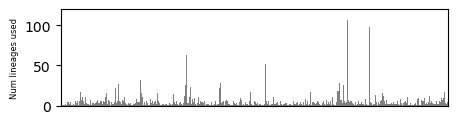

In [99]:
plt.figure(figsize=(5, 1.25))

values = list(fo2lineagesUsedNum_Full.values())
x = range(len(values))
plt.bar(x, values, color='gray', alpha=1, width=1.0)

plt.xlim([0, len(folditer2cpdNumFull.values())])
plt.xticks([])
plt.ylim([0, 120])
plt.ylabel('Num lineages used', fontsize=6)

# plt.savefig('folditer_lineage-usage.svg', dpi=300, bbox_inches='tight')
plt.show()

### overlay cpd discovery & lineage diversity

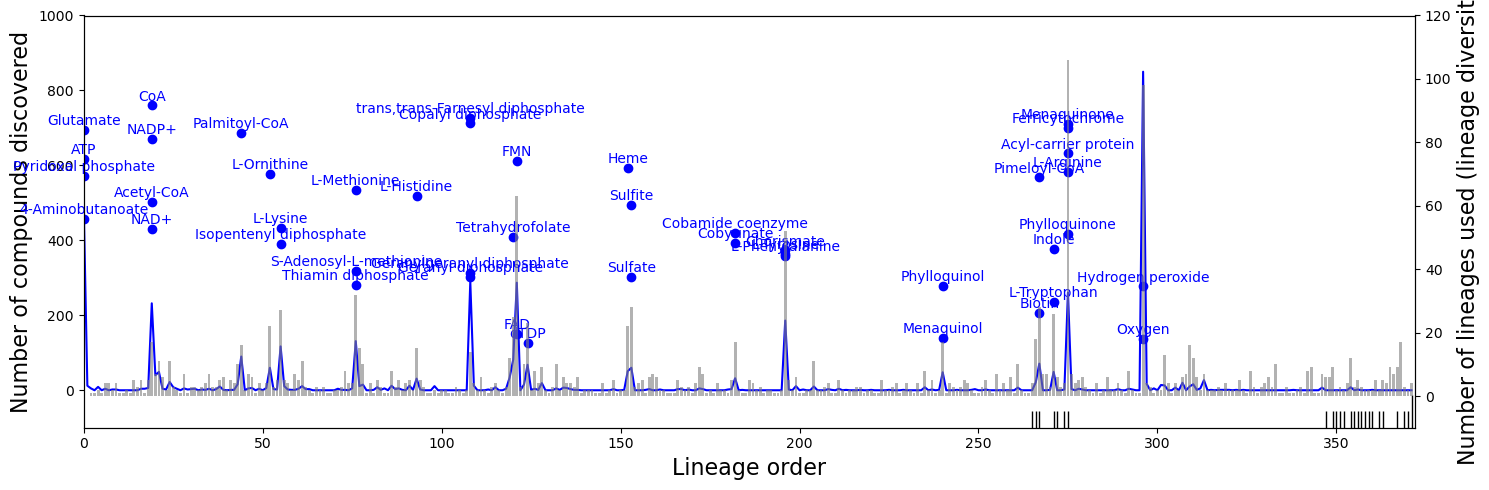

In [100]:
cpd2iter = {}
for cpd in ['C00006', 'C00154', 'C00077', 'C00047', 'C00135', 'C00073', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer

fig, ax1 = plt.subplots(figsize=(15, 5))

# First plot (line plot)
ax1.plot(folditer2cpdNumFull.values(), color='b', label='Line plot')
ax1.set_ylabel('Number of compounds discovered', fontsize=16)
ax1.set_ylim([-100, 1000])
ax1.set_xlim([0, len(folditer2cpdNumFull)])
ax1.set_xlabel('Lineage order', fontsize=16)

# Second y-axis for the bar plot
ax2 = ax1.twinx()
values = list(fo2lineagesUsedNum_Full.values())
x = range(len(values))
ax2.bar(x, values, color='gray', alpha=0.6, label='Bar plot')
ax2.set_ylabel('Number of lineages used (lineage diversity)', fontsize=16)
ax2.set_ylim([-10, 120])

# Add cpd annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    ax1.text(value, position, cpd2name[key], ha='center', va='bottom', color='b')
    ax1.scatter(value, position - 5, color='b')

# Add rugplots to ax1 (primary axis)
sns.rugplot(double_addition, height=0.04, color='k', ax=ax1)  # Double lineage addition
sns.rugplot(triple_addition, height=0.08, color='k', ax=ax1)  # Triple lineage addition

# Custom legend labels
# custom_labels = ['Compounds', 'lineage diversity']
# handles = lines + bars
# ax1.legend(handles, custom_labels, loc='upper left')

plt.tight_layout()
# plt.savefig('folditer_cpds_lineage_diversity.svg', dpi=300, bbox_inches='tight')
plt.show()

## folditer vs. new E.C. invention

In [101]:
# include the single usage

notches1 = {}
for x in x2usage.keys():
    fo2ec = {}
    for fo_ec in x2usage_ec1[x]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    current_ecs = set()
    for fo, ecs in fo2ec.items():
#         if ecs - current_ecs != set() and current_ecs != set():
        if ecs - current_ecs != set():
            if x not in notches1:
                notches1[x] = [fo]
            else:
                notches1[x].append(fo)
        current_ecs = current_ecs | ecs

notches2 = {}
for x in x2usage.keys():
    fo2ec = {}
    for fo_ec in x2usage_ec2[x]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    current_ecs = set()
    for fo, ecs in fo2ec.items():
#         if ecs - current_ecs != set() and current_ecs != set():
        if ecs - current_ecs != set():
            if x not in notches2:
                notches2[x] = [fo]
            else:
                notches2[x].append(fo)
        current_ecs = current_ecs | ecs

In [102]:
fo2inventions1 = {}
for x, fos in notches1.items():
    for fo in fos:
        if fo not in fo2inventions1: 
            fo2inventions1[fo] = 1
        else:
            fo2inventions1[fo] += 1

fo2inventions1_Full = {}
for i in range(0, max(fo2inventions1.keys())+1):
    if i not in fo2inventions1.keys():
        fo2inventions1_Full[i] = 0
    else:
        fo2inventions1_Full[i] = fo2inventions1[i]
print(len(fo2inventions1_Full))

fo2inventions2 = {}
for x, fos in notches2.items():
    for fo in fos:
        if fo not in fo2inventions2: 
            fo2inventions2[fo] = 1
        else:
            fo2inventions2[fo] += 1

fo2inventions2_Full = {}
for i in range(0, max(fo2inventions2.keys())+1):
    if i not in fo2inventions2.keys():
        fo2inventions2_Full[i] = 0
    else:
        fo2inventions2_Full[i] = fo2inventions2[i]
print(len(fo2inventions2_Full))

372
372


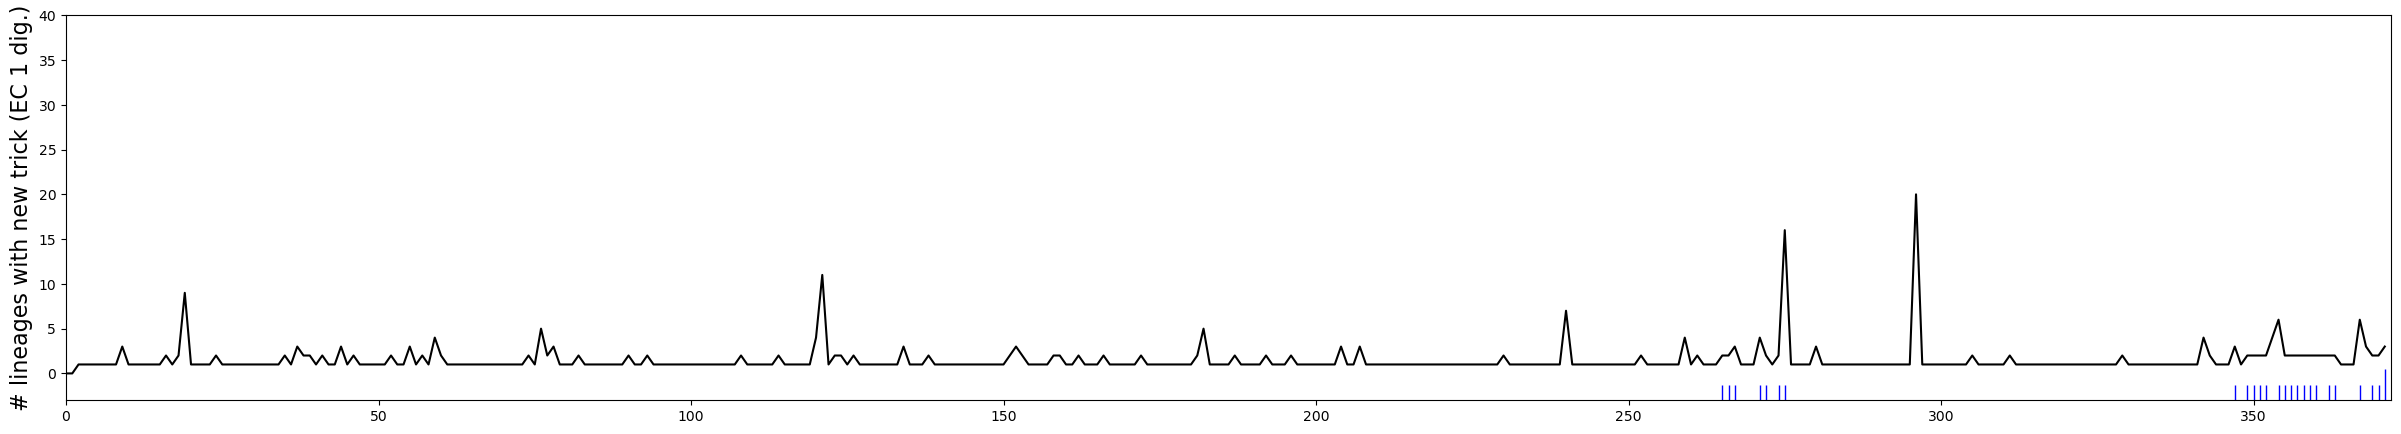

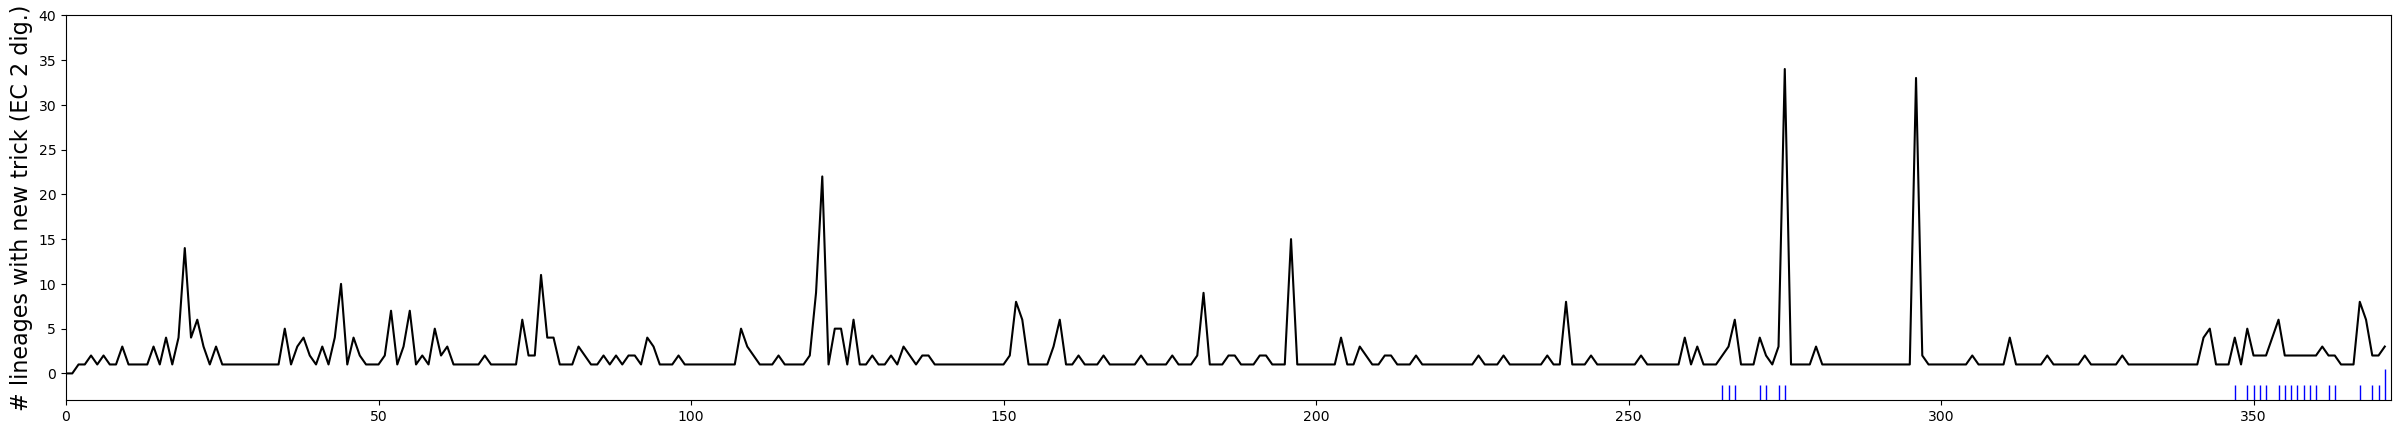

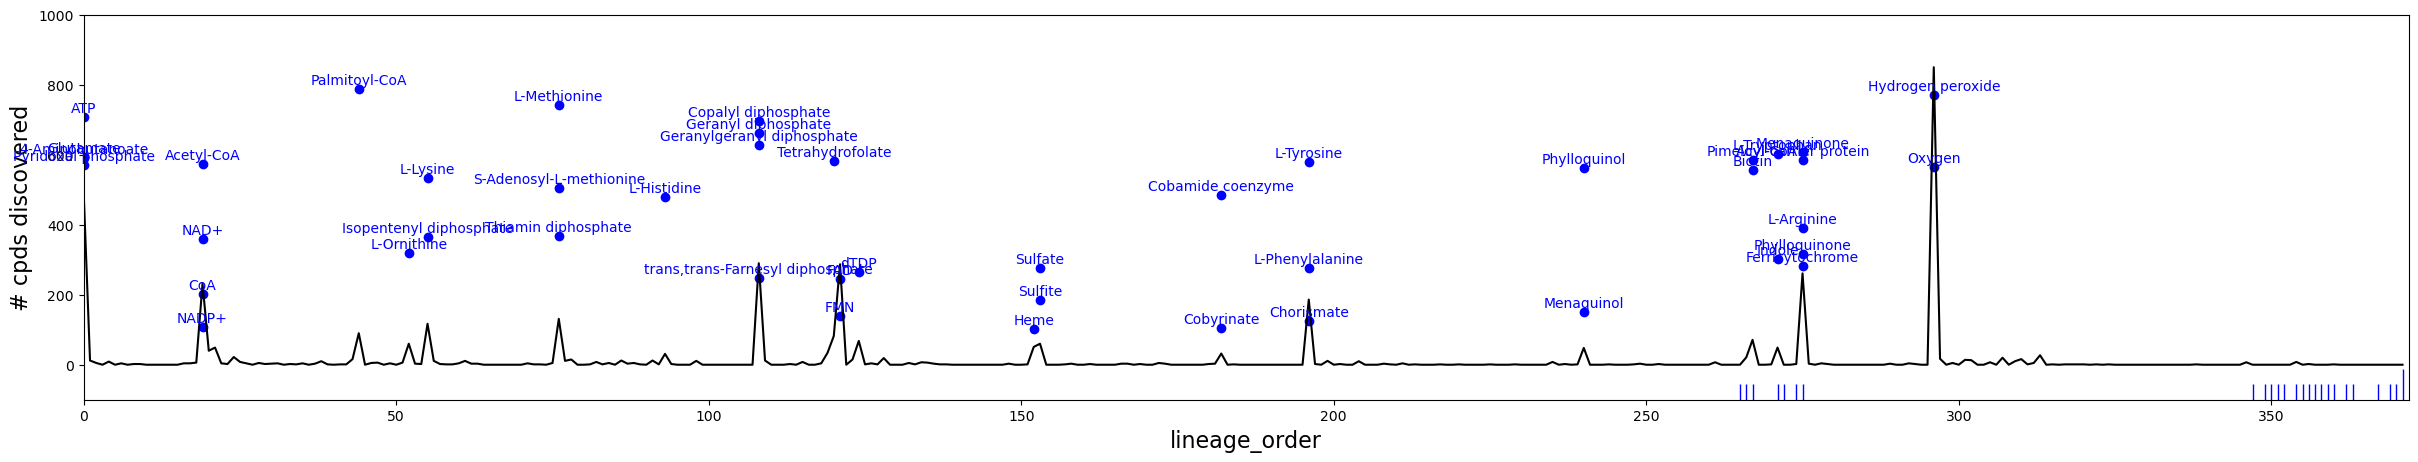

In [103]:
plt.figure(figsize=(30, 5))
plt.plot(fo2inventions1_Full.values(), color='k')

# Create a rugplot
sns.rugplot(double_addition, height=0.04, color='blue')  # double lineage addition
sns.rugplot(triple_addition, height=0.08, color='blue')  # triple lineage addition

plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-3,40])
plt.ylabel('# lineages with new trick (EC 1 dig.)', fontsize=16)
# plt.savefig('folditer_lineage_diversity.svg', dpi=300, bbox_inches='tight')
plt.show()



plt.figure(figsize=(30, 5))
plt.plot(fo2inventions2_Full.values(), color='k')

# Create a rugplot
sns.rugplot(double_addition, height=0.04, color='blue')  # double lineage addition
sns.rugplot(triple_addition, height=0.08, color='blue')  # triple lineage addition

plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-3,40])
plt.ylabel('# lineages with new trick (EC 2 dig.)', fontsize=16)
# plt.savefig('folditer_lineage_diversity.svg', dpi=300, bbox_inches='tight')
plt.show()



# compare with cpd discovery
cpd2iter = {}
for cpd in ['C00006', 'C00154', 'C00077', 'C00047', 'C00135', 'C00073', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

# Create a rugplot
sns.rugplot(double_addition, height=0.04, color='blue')  # double lineage addition
sns.rugplot(triple_addition, height=0.08, color='blue')  # triple lineage addition
    
plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
plt.xlabel('lineage_order', fontsize=16)
plt.ylabel('# cpds discovered', fontsize=16)
# plt.savefig('folditer_cpds_annotated_2.svg', dpi=300, bbox_inches='tight')
plt.show()

## #usage vs. #rules - scatter

In [104]:
x2rulesNum_scope = csv2dict('../data/assets/xgroup2/xgroup2rulesNum_scope.csv')

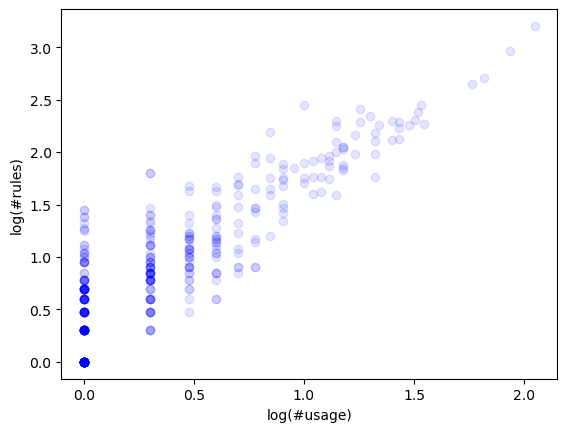

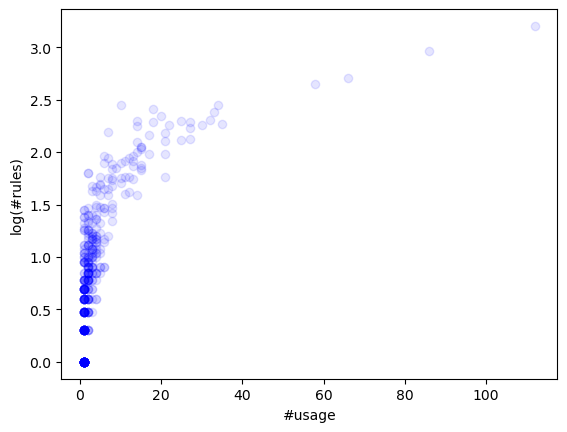

In [105]:
# some lineages with many rules are used in one folditer!

x2usageNum = {x:len(usage) for x, usage in x2usage.items()}
loglog(x2usageNum, x2rulesNum_scope, 'log(#usage)', 'log(#rules)')
ylog(x2usageNum, x2rulesNum_scope, '#usage', 'log(#rules)')

In [106]:
d1 = x2usageNum
d2 = x2rulesNum_scope

# output_file("mean_folditer_vs_escore_RUN.html")
p = figure(width=800, height=800)

# Add annotations
valid_keys, data1, data2 = todata(d1, d2)
data1 = np.log10(data1)
data2 = np.log10(data2)

# Use a red colormap
colormap = plt.cm.Blues
scalar_mappable = ScalarMappable(cmap=colormap)
colors = scalar_mappable.to_rgba([x2ds[x] for x in valid_keys if x in x2ds])
colors = ['#ff7f0e' if key in group1 else '#1f77b4' for key in valid_keys]

source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in valid_keys], 'ds': [x2ds[key] for key in valid_keys], 
          'color': colors, 'num_rules': [str(x2rulesNum_scope[key]) for key in valid_keys]}
p.scatter('x', 'y', source=source, size=10, color='color', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("X", "@label"), ("#rules", "@num_rules"), ("ds", "@ds")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = '#usage'
p.yaxis.axis_label = '#rules_scope'
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [107]:
single_use = [x for x in x2usageNum.keys() if x2usageNum[x] == 1]
len(single_use)

180

In [108]:
print(single_use)

['4004', '4021', '3699', '4081', '7589', '7529', '239', '7560', '3691', '62', '7534', '7500', '7580', '3883', '266', '133', '7509', '2493', '3754', '7554', '172', '3257', '3847', '629', '873', '270', '7549', '7520', '307', '387', '3599', '6113', '3654', '3651', '3292', '4262', '7536', '3086', '355', '377', '611', '812', '3117', '3009', '284', '875', '164', '582', '7513', '4237', '650', '3001', '305', '64', '197', '3685', '4022', '7562', '2496', '237', '235', '1114', '154', '4111', '253', '6096', '4295', '842', '1055', '7551', '285', '6075', '1077', '3076', '632', '7540', '814', '1144', '5067', '525', '4049', '319', '5103', '309', '185', '920', '378', '4018', '7587', '2008', '1119', '184', '7544', '4114', '2010', '590', '3052', '7568', '3371', '139', '73', '69', '313', '374', '6051', '199', '303', '3997', '146', '867', '914', '257', '7', '3249', '6166', '557', '158', '4294', '9', '640', '3978', '4983', '4110', '6174', '608', '620', '4159', '6', '4161', '3752', '3294', '196', '911', '241

In [109]:
set(group1) & set(single_use)

{'184', '253', '3997', '7544', '875'}

In [110]:
for x in set(group1) & set(single_use):
    print(x, x2rulesNum_scope[x])

253 1
3997 1
184 11
875 1
7544 11


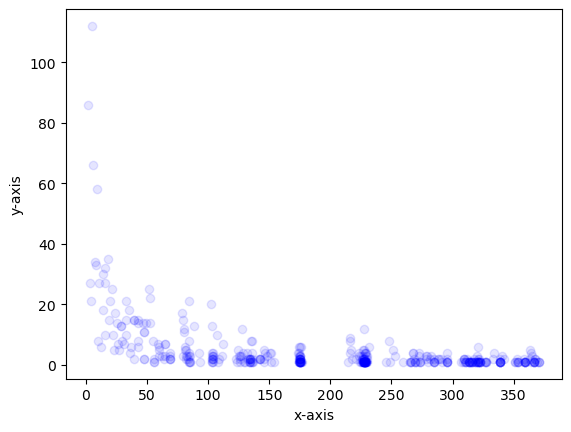

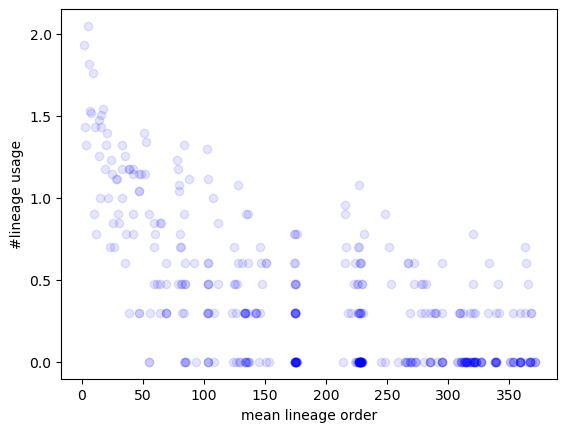

In [111]:
scatter(x2foMean, x2usageNum)
ylog(x2foMean, x2usageNum, 'mean lineage order', '#lineage usage')

# Do first-reactions always have the lineage that was injected at that cumiter?

In [112]:
# The answer is - YES

# for run in df_cpds_folditer.columns:
#     cumiter2rules = {}
#     for rule, i in df_rules_cumiter[run].items():
#         if i not in cumiter2rules:
#             cumiter2rules[i] = [eval(rule)]  # convert string into tuple with 'eval'
#         else:
#             cumiter2rules[i].append(eval(rule))
    
#     cumiter2lineages = {}
#     for x, cumiter in df_folds_cumiter[run].items():
#         if cumiter not in cumiter2lineages:
#             cumiter2lineages[cumiter] = [x]
#         else:
#             cumiter2lineages[cumiter].append(x)
    
#     for i, rnRules in cumiter2rules.items():
#         if i in cumiter2lineages.keys():  # check cumiters with lineage addition
#             lineages = cumiter2lineages[i]
#             for rnRule in rnRules:
#                 for x in lineages:  # check all lineages (multi-addition possible)
#                     if x not in rnRule[1]:
#                         print(f'{x} not in rule: {rnRule[1]}')

# Only use rules with one lineage (solo domain vs. multi-domain enzymes)

In [113]:
rn2rules_solo = {}
for rn, rules in rn2rules.items():
    new_rules = set()
    for rule in rules:
        if len(rule) == 1:
            new_rules.add(rule)
    rn2rules_solo[rn] = new_rules

# remove reactions with no solo rules
rn2rules_solo = {k:v for k,v in rn2rules_solo.items() if len(v) > 0}

In [114]:
len(rns_scope)

7678

In [115]:
len(rn2rules), len(set(rn2rules.keys()) & set(rns_scope))

(12872, 5730)

In [116]:
len(rn2rules_solo), len(set(rn2rules_solo.keys()) & set(rns_scope))

(8715, 3819)

In [117]:
rn2rules_solo

{'R01015': {frozenset({'2002'})},
 'R01070': {frozenset({'2002'}), frozenset({'304'})},
 'R01786': {frozenset({'2484'})},
 'R02740': {frozenset({'10'}), frozenset({'2002'}), frozenset({'2007'})},
 'R09084': {frozenset({'2003'})},
 'R02189': {frozenset({'2484'})},
 'R09085': {frozenset({'2003'})},
 'R01518': {frozenset({'7525'})},
 'R00431': {frozenset({'2004'})},
 'R00726': {frozenset({'2004'})},
 'R00341': {frozenset({'2004'})},
 'R04780': {frozenset({'246'}), frozenset({'304'})},
 'R01827': {frozenset({'2002'})},
 'R02739': {frozenset({'10'}), frozenset({'2002'}), frozenset({'2007'})},
 'R10907': {frozenset({'2003'})},
 'R01056': {frozenset({'7560'})},
 'R01529': {frozenset({'2002'})},
 'R02035': {frozenset({'2003'}), frozenset({'5'})},
 'R01049': {frozenset({'7573'})},
 'R05605': {frozenset({'2002'})},
 'R00709': {frozenset({'7510'})},
 'R00268': {frozenset({'7510'})},
 'R00267': {frozenset({'7510'})},
 'R00351': {frozenset({'2002'}), frozenset({'172'})},
 'R01899': {frozenset({'751

In [118]:
# dict2csv(rn2rules_solo, 'rn2rules_solo.csv')

In [119]:
def getCpdUsingLineages(cpd, direct_cpd_rn_set):
    
    # get all reactions that use given cpd
    if cpd.startswith('C'):
        # just use one run to get using/producing reactions
        run = '87452'
        using, both, producing = getUsingProducingRns(run, cpd, direct_cpd_rn_set)
    
        my_rns = (set(using) | set(both.keys())) & set(rn2rules_solo.keys())  # use + both in solo

    else:
        my_rns = direct_cpd_rn_set & set(rn2rules_solo.keys())
    
    
    cpd_using_lineages = set() 
    for rn in my_rns:
        for x in rn2rules_solo[rn]:  # for each lineage
            cpd_using_lineages.update(x)  # Add elements from the lineage
    
    if 'spontaneous' in cpd_using_lineages:
        cpd_using_lineages.remove('spontaneous')
    
    return cpd_using_lineages



cpd = 'Z00009'
direct_cpd_rn_set = getDirectRns(cpd) & set(result.scope.rns)
cuf = getCpdUsingLineages(cpd, direct_cpd_rn_set)
len(cuf)

2

In [120]:
rn2direction.pop('\ufeffC00404_syn')
rn2direction['C00404_syn'] = 'forward'

In [121]:
cpd2lineagesSolo = {}
for cpd in result.scope.cpds:
    direct_cpd_rn_set = getDirectRns(cpd) & set(result.scope.rns)
    cpd2lineagesSolo[cpd] = getCpdUsingLineages(cpd, direct_cpd_rn_set)

In [122]:
cpd2lineagesSolo

{'C20805': set(),
 'C03912': {'2002', '221', '2486', '7524'},
 'C19719': set(),
 'C18239': {'304', '325'},
 'C00101': {'1',
  '2002',
  '2003',
  '2004',
  '266',
  '304',
  '4093',
  '7501',
  '7571',
  '842'},
 'C00416': {'180', '2007', '304', '3086', '3896', '7558', '7579'},
 'C12124': {'2003'},
 'C01279': {'150', '2002', '2003', '281'},
 'C00100': {'1', '172', '2002', '2003', '2486', '7510', '7524', '7581'},
 'C01213': set(),
 'C04006': {'220', '7512', '7516'},
 'C19818': set(),
 'C21645': {'2003'},
 'C20404': {'10'},
 'C06473': {'2003'},
 'C05439': {'217'},
 'C22109': {'141'},
 'C05276': {'2486'},
 'C20158': set(),
 'C18797': {'7579'},
 'C22360': set(),
 'C00482': {'101', '2002', '7512', '7524'},
 'C00820': set(),
 'C01214': {'206', '7577'},
 'C21677': {'141'},
 'C08734': {'2002'},
 'C00027': {'136', '2485'},
 'C09723': set(),
 'C21560': {'149'},
 'C21021': set(),
 'C11388': set(),
 'C05608': {'2003'},
 'C17588': {'2003', '7567'},
 'C09664': set(),
 'C03401': set(),
 'C21007': {'2

In [123]:
# dict2csv(cpd2lineagesSolo, '../data/assets/cpd2lineagesSolo.csv')

# TableS_oxygen_category

In [124]:
len(ETU_O2), len(LTU_O2), len(NU_O2), len(IU_O2)

(24, 62, 242, 68)

In [125]:
FU_O2 = ETU_O2_using_loose - ETU_O2
len(FU_O2)

7

In [126]:
len(ETU_O2) + len(FU_O2) + len(LTU_O2) + len(NU_O2) + len(IU_O2)
# must remove FUs from LTUs

403

In [127]:
LTU_O2 = LTU_O2 - FU_O2
len(LTU_O2)

55

In [128]:
len(ETU_O2) + len(FU_O2) + len(LTU_O2) + len(NU_O2) + len(IU_O2)

396

In [129]:
print(IU_O2)

{'236', '141', '213', '3447', '7561', '3264', '4025', '3960', '4272', '5038', '7579', '2011', '103', '7552', '7512', '210', '7584', '4335', '316', '222', '219', '602', '4', '228', '2006', '196', '5084', '3456', '3281', '3994', '503', '107', '218', '7542', '2005', '279', '7524', '7525', '4046', '7581', '206', '5100', '7578', '3697', '608', '7567', '7515', '4019', '4194', '298', '7510', '315', '323', '9', '2487', '4952', '301', '3843', '371', '6166', '3740', '3579', '601', '268', '4024', '129', '4011', '1001'}


In [130]:
x2oxygen_category = {}
for x in x2foMean:
    if x in ETU_O2:
        x2oxygen_category[x] = 'ETU'
    elif x in FU_O2:
        x2oxygen_category[x] = 'FU'
    elif x in LTU_O2:
        x2oxygen_category[x] = 'LTU'
    elif x in IU_O2:
        x2oxygen_category[x] = 'IU'
    elif x in NU_O2:
        x2oxygen_category[x] = 'NU'
    else:
        print('this should not run')

In [131]:
x2oxygen_category_od = dict(sorted(x2oxygen_category.items(), key=lambda item: int(item[0])))

data = []
for x in x2oxygen_category_od.keys():
    data.append({
        'Lineage': x,
        'Name': x2name.get(x, 'NO XNAME'),
        'Category': x2oxygen_category_od[x]
    })

df = pd.DataFrame(data)  # Convert list of dicts to DataFrame
df.head()

,Lineage,Name,Category
0,1,cradle loop barrel,LTU
1,2,OB-fold,NU
2,4,SH3,IU
3,5,beta-propeller-like,LTU
4,6,NO XNAME,ETU


In [132]:
# df.to_csv('TableS_oxygen_category.csv', index=False)

# TableS_representative_run_cpds

In [133]:
cpd2name = csv2dict('../data/assets/cpd2name.csv')

In [134]:
data = []
for c in result.cpds_folditer.keys():
    data.append({
        'Iteration': result.cpds_folditer[c],
        'Compound ID': c,
        'Compound name': cpd2name.get(c, c)
    })

df = pd.DataFrame(data)  # Convert list of dicts to DataFrame
df.head()

,Iteration,Compound ID,Compound name
0,0,C20485,(4S)-4-Hydroxy-2-oxoglutarate; (S)-2-Hydroxy-4...
1,0,C07836,D-glycero-beta-D-manno-Heptose 7-phosphate
2,0,C01419,Cys-Gly; L-Cysteinylglycine
3,0,C00217,D-Glutamate; D-Glutamic acid; D-Glutaminic aci...
4,0,C00257,D-Gluconic acid; D-Gluconate; D-gluco-Hexonic ...


In [135]:
# df.to_csv('TableS_rep_run_cpds.csv', index=False)

# TableS_representative_run_lineages

In [136]:
data = []
for x in result.folds_folditer.keys():
    data.append({
        'Iteration': result.folds_folditer[x] - 1,  # ignore correct for 'fold_independent' and 'spontaneous'
        'Lineage': x,
        'Name': x2name.get(x, 'NO XNAME')
    })

df = pd.DataFrame(data)  # Convert list of dicts to DataFrame
df.head()

,Iteration,Lineage,Name
0,-1,fold_independent,NO XNAME
1,0,spontaneous,NO XNAME
2,1,2002,TIM beta/alpha-barrel
3,2,2006,HAD domain-like
4,3,2484,Ribonuclease H-like


In [137]:
# df.to_csv('TableS_rep_run_lineages.csv', index=False)

# ETU vs. LTU #reactions

In [138]:
len(using)

826

In [139]:
len(ETU_O2), len(FU_O2), len(LTU_O2), len(IU_O2), len(NU_O2)

(24, 7, 55, 68, 242)

In [140]:
len(ETU_O2) + len(FU_O2) + len(LTU_O2) + len(IU_O2) + len(NU_O2)

396

In [141]:
x2rn_scope_ETU_O2 = {k:len(v) for k,v in x2rn_scope.items() if k in ETU_O2}

x2rn_scope_ETU_O2_ox = {}
for k,v in x2rn_scope.items():
    if k in ETU_O2:
        v_ox = [r for r in v if r in using] 
        x2rn_scope_ETU_O2_ox[k] = len(v_ox)
for x, l in x2rn_scope_ETU_O2.items():
    print(x, l, x2rn_scope_ETU_O2_ox[x], x2rn_scope_ETU_O2_ox[x]/l)

3115 1 1 1.0
146 22 22 1.0
158 5 5 1.0
241 1 1 1.0
4983 4 4 1.0
6174 2 2 1.0
3752 1 1 1.0
6 2 2 1.0
262 15 15 1.0
7 6 6 1.0
4160 1 1 1.0
3978 4 4 1.0
603 2 2 1.0
3207 3 3 1.0
2012 10 10 1.0
557 5 5 1.0
3777 1 1 1.0
257 7 7 1.0
640 4 4 1.0
4110 2 2 1.0
3249 6 6 1.0
4159 2 2 1.0
881 1 1 1.0
4229 1 1 1.0


In [142]:
x2rn_scope_FU_O2 = {k:len(v) for k,v in x2rn_scope.items() if k in FU_O2}

x2rn_scope_FU_O2_ox = {}
for k,v in x2rn_scope.items():
    if k in FU_O2:
        v_ox = [r for r in v if r in using] 
        x2rn_scope_FU_O2_ox[k] = len(v_ox)
for x, l in x2rn_scope_FU_O2.items():
    print(x, l, x2rn_scope_FU_O2_ox[x], x2rn_scope_FU_O2_ox[x]/l)

620 2 1 0.5
914 9 8 0.8888888888888888
66 27 24 0.8888888888888888
4028 2 1 0.5
4294 22 20 0.9090909090909091
4048 2 1 0.5
867 12 2 0.16666666666666666


In [143]:
x2rn_scope_LTU_O2 = {k:len(v) for k,v in x2rn_scope.items() if k in LTU_O2}

LTU2oxRatio = {}
x2rn_scope_LTU_O2_ox = {}
for k,v in x2rn_scope.items():
    if k in LTU_O2:
        v_ox = [r for r in v if r in using] 
        x2rn_scope_LTU_O2_ox[k] = len(v_ox)
for x, l in x2rn_scope_LTU_O2.items():
    print(x, l, x2rn_scope_LTU_O2_ox[x], x2rn_scope_LTU_O2_ox[x]/l)
    LTU2oxRatio[x] = x2rn_scope_LTU_O2_ox[x]/l

4052 42 7 0.16666666666666666
205 56 1 0.017857142857142856
247 17 5 0.29411764705882354
244 217 111 0.511520737327189
3156 18 9 0.5
7514 73 37 0.5068493150684932
278 12 3 0.25
187 21 1 0.047619047619047616
633 50 5 0.1
2485 38 7 0.18421052631578946
150 37 15 0.40540540540540543
211 15 11 0.7333333333333333
149 153 118 0.7712418300653595
325 98 26 0.2653061224489796
5 74 26 0.35135135135135137
11 159 15 0.09433962264150944
604 12 3 0.25
243 90 74 0.8222222222222222
131 37 1 0.02702702702702703
101 118 3 0.025423728813559324
375 8 1 0.125
223 23 1 0.043478260869565216
302 4 1 0.25
3687 10 6 0.6
6058 5 1 0.2
12 156 52 0.3333333333333333
179 46 26 0.5652173913043478
10 211 87 0.41232227488151657
2484 122 1 0.00819672131147541
331 37 21 0.5675675675675675
230 20 3 0.15
221 131 28 0.21374045801526717
327 82 1 0.012195121951219513
192 6 2 0.3333333333333333
108 26 2 0.07692307692307693
217 90 41 0.45555555555555555
281 26 2 0.07692307692307693
7574 74 1 0.013513513513513514
209 6 2 0.3333333

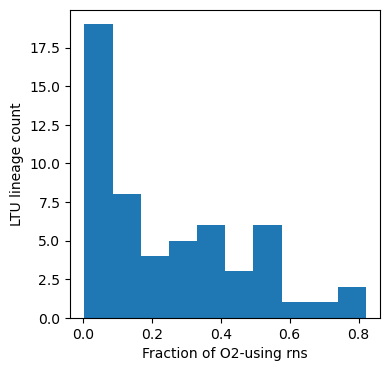

In [144]:
def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts', ylog=False, xlog=False):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.figure(figsize=(4, 4))
    
    plt.hist(data1, bins=bins, edgecolor=None)  # orientation='horizontal'
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)

    if ylog:
        plt.yscale('log', nonpositive='clip')
    if xlog:
        plt.xscale('log', nonpositive='clip')
    
    # plt.savefig(f'{x_axis}_{y_axis}.svg', dpi=300, bbox_inches='tight')
    plt.show()


histogram(LTU2oxRatio, x_axis='Fraction of O2-using rns', y_axis='LTU lineage count')

## are most generalists part-time O2 users?

In [145]:
x2rn_scopeNum = {k:len(v) for k,v in x2rn_scope.items()}
x2rn_scopeNum['2003']

1380

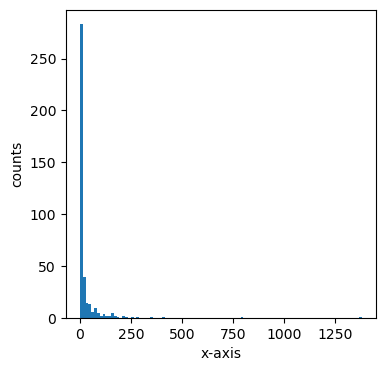

In [146]:
histogram(x2rn_scopeNum, bins=100)

In [147]:
generalists = [k for k,v in x2rn_scopeNum.items() if v >= 100]
len(generalists)

26

In [148]:
count = 0
for x in generalists:
    print(x in LTU_O2, x, x2rn_scopeNum[x], LTU2oxRatio.get(x,'not LTU'))
    if x in LTU_O2:
        count += 1
print(count/len(generalists))

False 236 135 not LTU
True 244 217 0.511520737327189
True 149 153 0.7712418300653595
False 141 277 not LTU
True 11 159 0.09433962264150944
False 2006 169 not LTU
True 101 118 0.025423728813559324
True 12 156 0.3333333333333333
False 7581 139 not LTU
True 10 211 0.41232227488151657
True 2484 122 0.00819672131147541
False 206 157 not LTU
True 221 131 0.21374045801526717
False 246 139 not LTU
False 7524 116 not LTU
False 222 102 not LTU
True 109 253 0.003952569169960474
True 304 354 0.08757062146892655
True 3016 178 0.02247191011235955
True 2004 165 0.01818181818181818
True 2007 413 0.021791767554479417
True 2002 789 0.026615969581749048
False 7512 125 not LTU
True 7577 186 0.021505376344086023
True 2003 1380 0.08260869565217391
True 1 230 0.18695652173913044
0.6538461538461539


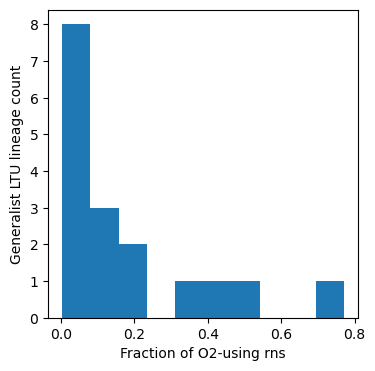

In [149]:
LTU2oxRatio_gen = {k:v for k,v in LTU2oxRatio.items() if k in generalists}
histogram(LTU2oxRatio_gen, x_axis='Fraction of O2-using rns', y_axis='Generalist LTU lineage count')

# IU fractions

In [150]:
x2rn_scope_IU_O2 = {k:len(v) for k,v in x2rn_scope.items() if k in IU_O2}

IU2oxRatio = {}
x2rn_scope_IU_O2_ox = {}
for k,v in x2rn_scope.items():
    if k in IU_O2:
        v_ox = [r for r in v if r in indirectO2 or r in producing]  # indirect or O2 producing
        x2rn_scope_IU_O2_ox[k] = len(v_ox)
for x, l in x2rn_scope_IU_O2.items():
    print(x, l, x2rn_scope_IU_O2_ox[x], x2rn_scope_IU_O2_ox[x]/l)
    IU2oxRatio[x] = x2rn_scope_IU_O2_ox[x]/l

7561 15 8 0.5333333333333333
601 10 4 0.4
3697 6 2 0.3333333333333333
236 135 8 0.05925925925925926
323 68 17 0.25
7510 42 1 0.023809523809523808
371 5 2 0.4
608 2 1 0.5
3281 4 4 1.0
4194 16 8 0.5
4025 6 4 0.6666666666666666
141 277 9 0.032490974729241874
3843 3 3 1.0
316 6 1 0.16666666666666666
7515 55 2 0.03636363636363636
196 1 1 1.0
2006 169 2 0.011834319526627219
2487 82 4 0.04878048780487805
279 50 3 0.06
2011 49 1 0.02040816326530612
2005 63 1 0.015873015873015872
213 34 3 0.08823529411764706
268 4 3 0.75
3740 8 2 0.25
7525 48 1 0.020833333333333332
5084 10 3 0.3
4024 2 1 0.5
9 5 4 0.8
3264 7 2 0.2857142857142857
7581 139 3 0.02158273381294964
298 84 4 0.047619047619047616
4046 1 1 1.0
7578 3 1 0.3333333333333333
206 157 8 0.050955414012738856
7579 93 22 0.23655913978494625
301 57 2 0.03508771929824561
219 25 5 0.2
7542 41 1 0.024390243902439025
218 32 3 0.09375
228 4 4 1.0
103 45 1 0.022222222222222223
4011 67 3 0.04477611940298507
4335 7 2 0.2857142857142857
7524 116 13 0.1120

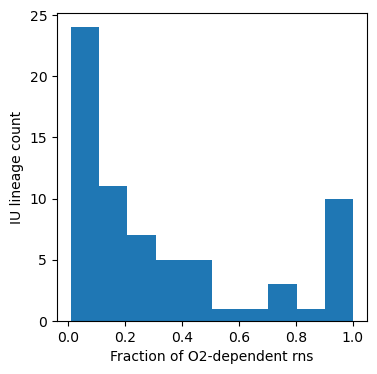

In [151]:
histogram(IU2oxRatio, x_axis='Fraction of O2-dependent rns', y_axis='IU lineage count')

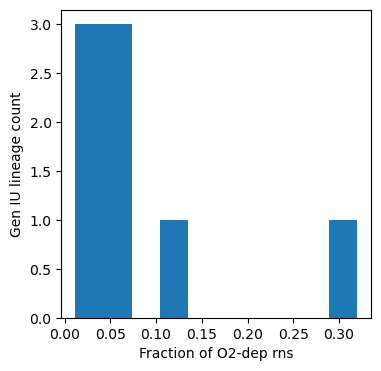

In [152]:
IU2oxRatio_gen = {k:v for k,v in IU2oxRatio.items() if k in generalists}
histogram(IU2oxRatio_gen, x_axis='Fraction of O2-dep rns', y_axis='Gen IU lineage count')